In [1]:
## Business objective
# The objective of this notebook is to prepare the data for building a Behavioural Probability of Default (PD) model.
# The model predicts whether a currently non-defaulted account will default within the next 12 months using behavioural, bureau,
# demographic, product and account information available at the snapshot date.
# Current defaulted accounts are excluded because Behavioural PD models estimate the probability of future default for performing accounts.

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from optbinning import BinningProcess
from optbinning import OptimalBinning

import statsmodels.api as sm

from sklearn.metrics import roc_curve, roc_auc_score


In [3]:
data_path = Path("../data/raw/dataset")

## Loading Dataset

In [4]:
csv_files = sorted(data_path.glob("*.csv"))

print(f"Number of files: {len(csv_files)}")
csv_files


Number of files: 10


[WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part01.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part02.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part03.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part04.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part05.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part06.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part07.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part08.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part09.csv'),
 WindowsPath('../data/raw/dataset/credit_risk_pd_dataset_part10.csv')]

In [5]:
loan_data = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True)

loan_data.columns = loan_data.columns.str.lower()


In [6]:
# renaming columns
loan_data.rename(
    columns= {
        'default_flag': 'is_currently_default',  # status AT the snapshot date (not the target)
        'target_default_12m_flag': 'target'      # status 12 months AFTER the snapshot date
    }, inplace= True
)

In [7]:
loan_data.shape

(1000000, 88)

In [8]:
pd.set_option('display.max_columns', None)
loan_data.head()

,cust_id,acct_id,appl_id,snapshot_dt,acct_open_dt,portfolio_segment_cd,age,gender_cd,marital_sts_cd,emp_sts_cd,emp_length_yrs,annual_inc_amt,residence_type_cd,state_cd,product_cd,card_type_cd,mob_cnt,credit_limit_amt,orig_credit_limit_amt,interest_rate_pct,annual_fee_amt,bureau_score,bureau_score_2,total_trades_cnt,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_curr_delinq_bucket_cd,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,b_overlimit_flag,s_spend_1m_amt,s_spend_3m_amt,s_spend_12m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,r_behav_score,r_application_score,r_collections_score,r_attrition_score,r_fraud_score,target,is_currently_default,default_dt,days_in_default_cnt,collateral_type_cd,collateral_value_amt,secured_flag,workout_status_cd,recovery_amt,undrawn_limit_amt,drawn_exposure_amt,ead_amt,gdp_growth_rate,unemployment_rate,hpi_index,benchmark_int_rate,macro_scenario_cd,dev_oot_flag,data_quality_flag
0,6bf470643060584b,097283fdca5b6d2d,efd1acb86480,2023-04-01,2017-07-01,CONSUMER_CARD,27,M,D,FT,0.9,60428.04,MTG,VA,PLATINUM,CONSUMER,70,4575.60,2729.90,19.06,0,698.0,704.0,29,13,0,0,1,33240.23,0.5501,0,0,0,0,0,0,0,999.0,C,0,0,1593.68,1625.67,1907.63,2186.87,495.91,885.82,0.3483,0.3553,0,472.30,1295.03,5600.13,41,11.52,0.00,0,31.87,809.59,0.5080,9,1.0,0,0,734.0,705.0,702.0,345.0,558.0,0,0,NaN,0,NONE,0.0,0,NONE,0.0,2981.92,1593.68,0.0,2.09,4.20,101.31,5.40,BASELINE,VALIDATION,OK
1,6086a3e2eec4b57b,7c58f536e80664ff,2ee9948a5098,2024-07-24,2021-09-08,CONSUMER_CARD,26,F,M,FT,3.6,15000.00,RENT,VA,GREEN,CONSUMER,35,21283.74,14635.45,22.94,0,542.0,545.0,15,13,1,2,4,6640.80,0.4427,73,73,73,1,2,1,0,0.0,60-89,0,0,15918.11,17608.81,14783.54,22835.30,13030.36,12635.49,0.7479,0.8273,0,1370.18,3890.47,15865.89,53,25.85,98.01,0,318.36,5445.59,0.3421,10,11.0,1,1,623.0,611.0,531.0,427.0,384.0,0,0,NaN,0,NONE,0.0,0,NONE,0.0,5365.63,15918.11,0.0,1.14,5.38,105.82,4.90,UPSIDE,OUT_OF_TIME,REVIEW
2,4027d7d8e22ae6de,5ba6fefc2f6467d1,4556eec2cce1,2024-04-25,2023-03-02,CONSUMER_CARD,50,F,D,FT,0.6,40712.48,OWN,CA,CASHBACK,CONSUMER,14,2185.43,1240.30,19.23,550,843.0,825.0,18,14,0,0,0,17470.21,0.4291,0,0,0,0,0,0,0,999.0,C,0,0,603.18,659.98,485.54,677.85,158.90,435.61,0.2760,0.3020,0,100.26,301.26,1035.27,17,5.90,0.00,0,25.00,569.34,0.9439,12,2.0,0,0,850.0,850.0,812.0,388.0,487.0,0,0,NaN,0,NONE,0.0,0,NONE,0.0,1582.25,603.18,0.0,1.39,4.95,104.63,4.69,UPSIDE,DEVELOPMENT,OK
3,4ce73a161d37692b,6a342a2d294874fc,7f13b8def759,2023-11-27,2013-05-23,CONSUMER_CARD,43,F,S,FT,0.7,91591.57,OTH,MA,GOLD,CONSUMER,128,3653.63,2807.00,14.80,95,773.0,758.0,18,14,0,0,0,51241.32,0.5595,0,0,0,0,0,0,0,999.0,C,0,0,572.16,512.91,587.20,607.85,297.56,383.25,0.1566,0.1404,0,50.87,200.30,890.90,44,1.16,0.00,0,25.00,459.67,0.8034,12,4.0,0,0,850.0,753.0,797.0,597.0,499.0,0,0,NaN,0,NONE,0.0,0,NONE,0.0,3081.47,572.16,0.0,2.79,4.13,103.27,4.65,BASELINE,DEVELOPMENT,OK
4,5deb41f0feebd45f,3eb697a1dc906be5,f7adea4dbbcc,2023-11-27,2021-07-10,CONSUMER_CARD,22,M,M,SE,4.5,34539.30,RENT,GA,BLUE,CONSUMER,29,8631.98,6686.58,25.88,95,665.0,658.0,24,9,1,0,0,14189.01,0.4108,0,0,16,0,0,0,0,999.0,C,0,0,4068.25,3876.01,3824.26,5086.37,1195.59,3029.19,0.4713,0.4490,0,78.53,256.24,1122.10,1,78.53,5.57,0,81.36,1507.69,0.3706,10,2.0,0,0,714.0,675.0,581.0,293.0,351.0,0,0,NaN,0,NONE,0.0,0,NONE,0.0,4563.73,4068.25,0.0,2.79,4.13,103.27,4.65,BASELINE,DEVELOPMENT,OK


In [9]:
print("Data Types")
print(loan_data.dtypes.value_counts())

Data Types
float64    41
int64      27
object     20
Name: count, dtype: int64


In [10]:
missing_summary = loan_data.isnull().sum().sort_values(ascending=False)
missing_summary.head(10)

default_dt                     977953
emp_length_yrs                  40030
bureau_score_2                  30029
d_mob_since_last_delinq_cnt     20122
dti_ratio                       20052
p_days_since_last_pay_cnt       19932
collateral_value_amt             9887
cust_id                             0
p_actual_pay_amt                    0
p_nsf_12m_cnt                       0
dtype: int64

### Data Quality checks

In [11]:
print(f"Duplicate rows: {loan_data.duplicated().sum()}")
print(f"Duplicate account-month rows: {loan_data.duplicated(subset= ['acct_id', 'snapshot_dt']).sum()}")

Duplicate rows: 0
Duplicate account-month rows: 0


In [12]:
print(f"INQ_12M_CNT < INQ_6M_CNT: {(loan_data['inq_12m_cnt'] < loan_data['inq_6m_cnt']).sum()}")
print(f"open_trades_cnt > total_trades_cnt: {(loan_data['open_trades_cnt'] > loan_data['total_trades_cnt']).sum()}")
print(f"d_dpd_max_12m_cnt < d_dpd_max_6m_cnt: {(loan_data['d_dpd_max_12m_cnt'] < loan_data['d_dpd_max_6m_cnt']).sum()}")
print(f"d_times_30dpd_12m_cnt < d_times_30dpd_6m_cnt: {(loan_data['d_times_30dpd_12m_cnt'] < loan_data['d_times_30dpd_6m_cnt']).sum()}")
print(f"b_curr_bal_amt > b_max_bal_12m_amt: {(loan_data['b_curr_bal_amt'] > loan_data['b_max_bal_12m_amt']).sum()}")
print(f"p_ontime_pay_12m_cnt > 12: {(loan_data['p_ontime_pay_12m_cnt'] > 12).sum()}")


INQ_12M_CNT < INQ_6M_CNT: 0
open_trades_cnt > total_trades_cnt: 0
d_dpd_max_12m_cnt < d_dpd_max_6m_cnt: 0
d_times_30dpd_12m_cnt < d_times_30dpd_6m_cnt: 0
b_curr_bal_amt > b_max_bal_12m_amt: 0
p_ontime_pay_12m_cnt > 12: 0


In [13]:
# Utilization should generally be between 0 and 1, with some over-limit accounts >1
loan_data["b_util_ratio"].describe()

count    1000000.000000
mean           0.356785
std            0.220717
min            0.000000
25%            0.191800
50%            0.349700
75%            0.507800
max            1.437900
Name: b_util_ratio, dtype: float64

In [14]:
# Check balance distribution and identify extreme values
loan_data["b_curr_bal_amt"].describe()

count    1000000.000000
mean        2240.442115
std         2513.942667
min            0.000000
25%          688.660000
50%         1529.790000
75%         2926.500000
max        79002.510000
Name: b_curr_bal_amt, dtype: float64

In [15]:
date_cols= [col for col in loan_data.columns if col.endswith("_dt")]
date_cols


['snapshot_dt', 'acct_open_dt', 'default_dt']

In [16]:
# Converting date columns
loan_data[date_cols]= loan_data[date_cols].apply(
    pd.to_datetime, errors= "coerce"
)


In [17]:
loan_data[date_cols].dtypes

snapshot_dt     datetime64[ns]
acct_open_dt    datetime64[ns]
default_dt      datetime64[ns]
dtype: object

In [18]:
invalid_dates= (loan_data['acct_open_dt'] > loan_data['snapshot_dt']).sum()
print(f"Invalid account dates: {invalid_dates}")


Invalid account dates: 0


In [19]:
# target variable distribution
target_summary= loan_data['target'].value_counts().reset_index(name="count")
target_summary['percentage']= (target_summary['count']/ len(loan_data)) * 100
target_summary

,target,count,percentage
0,0,958584,95.8584
1,1,41416,4.1416


In [20]:
# split flag distribution
loan_data["dev_oot_flag"].value_counts(dropna=False)

dev_oot_flag
DEVELOPMENT    615547
OUT_OF_TIME    249465
VALIDATION     134988
Name: count, dtype: int64

In [21]:
loan_data['is_currently_default'].value_counts(normalize= True)

is_currently_default
0    0.977953
1    0.022047
Name: proportion, dtype: float64

## Behavioural PD Population

In [22]:
# replacing 999 for never deliquent with -1
loan_data['d_mob_since_last_delinq_cnt']= (
    loan_data['d_mob_since_last_delinq_cnt'].replace(999, -1)
)

In [23]:
pd_population= loan_data[loan_data['is_currently_default']== 0].copy()

In [24]:
print(f'Full dataset shape: {loan_data.shape}')
print(f'Behavioural PD Population: {pd_population.shape}')
print(f'Bad rate: {pd_population["target"].mean(): .2%}')

Full dataset shape: (1000000, 88)
Behavioural PD Population: (977953, 88)
Bad rate:  3.62%


In [25]:
loan_data['is_currently_default'].value_counts()

is_currently_default
0    977953
1     22047
Name: count, dtype: int64

### Development/ Validation/ Out of Time Split

In [26]:
development_data= pd_population[pd_population['dev_oot_flag']== 'DEVELOPMENT'].copy()
validation_data= pd_population[pd_population['dev_oot_flag']== 'VALIDATION'].copy()
oot_data= pd_population[pd_population['dev_oot_flag']== 'OUT_OF_TIME'].copy()

In [27]:
print(f"Development Shape: {development_data.shape}")
print(f"Validation Shape:  {validation_data.shape}")
print(f"OOT Shape:         {oot_data.shape}")

Development Shape: (602033, 88)
Validation Shape:  (131961, 88)
OOT Shape:         (243959, 88)


In [28]:
print("Development")
print(development_data["target"].value_counts(normalize=True))

print("\nValidation")
print(validation_data["target"].value_counts(normalize=True))

print("\nOOT")
print(oot_data["target"].value_counts(normalize=True))

Development
target
0    0.963964
1    0.036036
Name: proportion, dtype: float64

Validation
target
0    0.963391
1    0.036609
Name: proportion, dtype: float64

OOT
target
0    0.963809
1    0.036191
Name: proportion, dtype: float64


## Preprocessing

In [29]:
# removing variables not required for behavioural PD
drop_columns = [

    # Existing risk scores
    "r_behav_score",
    "r_application_score",
    "r_collections_score",
    "r_attrition_score",
    "r_fraud_score",

    # LGD / EAD variables
    "default_dt",
    "days_in_default_cnt",
    "collateral_type_cd",
    "collateral_value_amt",
    "secured_flag",
    "workout_status_cd",
    "recovery_amt",
    "undrawn_limit_amt",
    "drawn_exposure_amt",
    "ead_amt"
]

development_data.drop(columns=drop_columns, inplace=True)

validation_data.drop(columns=drop_columns, inplace=True)

oot_data.drop(columns=drop_columns, inplace=True)

In [30]:
# dropping dev_oot_flag
development_data.drop(columns="dev_oot_flag", inplace=True)
validation_data.drop(columns="dev_oot_flag", inplace=True)
oot_data.drop(columns="dev_oot_flag", inplace=True)

In [31]:
# missing values- development data
missing_summary= development_data.isnull().sum().to_frame('count')

missing_summary['missing_pct']= (missing_summary['count']/ len(development_data)) * 100

missing_summary= missing_summary[missing_summary['count']> 0].sort_values(by='missing_pct', ascending= False)

missing_summary


,count,missing_pct
emp_length_yrs,23985,3.984001
bureau_score_2,18054,2.998839
d_mob_since_last_delinq_cnt,12235,2.032281
p_days_since_last_pay_cnt,12042,2.000223
dti_ratio,11925,1.980788


In [32]:
# emp_length_yrs
development_data['emp_length_yrs'].describe()

count    578048.000000
mean          5.001955
std           4.985976
min           0.000000
25%           1.400000
50%           3.500000
75%           6.900000
max          40.000000
Name: emp_length_yrs, dtype: float64

In [33]:
# median of the development data
emp_length_median = development_data["emp_length_yrs"].median()

development_data["emp_length_yrs"] = (
    development_data["emp_length_yrs"].fillna(emp_length_median)
)

validation_data["emp_length_yrs"] = (
    validation_data["emp_length_yrs"].fillna(emp_length_median)
)

oot_data["emp_length_yrs"] = (
    oot_data["emp_length_yrs"].fillna(emp_length_median)
)

In [34]:
# bureau_score_2
development_data["bureau_score_2"].describe()

count    583979.000000
mean        701.667060
std          83.613957
min         357.000000
25%         643.000000
50%         702.000000
75%         763.000000
max         850.000000
Name: bureau_score_2, dtype: float64

In [35]:
bureau_score_2_median = development_data["bureau_score_2"].median()

development_data["bureau_score_2"]= development_data["bureau_score_2"].fillna(bureau_score_2_median)
validation_data["bureau_score_2"]= validation_data["bureau_score_2"].fillna(bureau_score_2_median)
oot_data["bureau_score_2"]= oot_data["bureau_score_2"].fillna(bureau_score_2_median)

In [36]:
# d_mob_since_last_delinq_cnt
development_data["d_mob_since_last_delinq_cnt"].describe()

count    589798.000000
mean         -0.407316
std           1.889348
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          -1.000000
max          11.000000
Name: d_mob_since_last_delinq_cnt, dtype: float64

<Axes: >

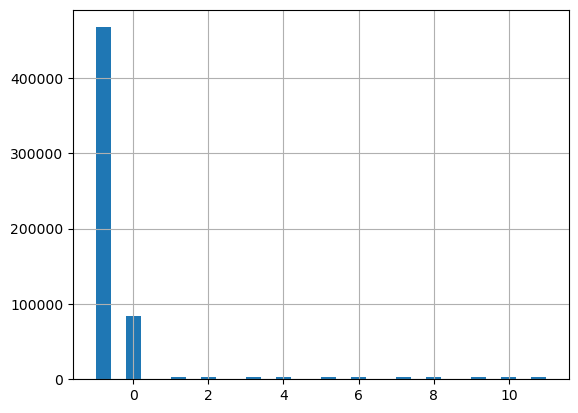

In [37]:
development_data["d_mob_since_last_delinq_cnt"].hist(bins=30)

In [38]:
d_mob_since_last_delinq_median = (
    development_data[development_data['d_mob_since_last_delinq_cnt']!= -1]['d_mob_since_last_delinq_cnt'].median()
)

development_data["d_mob_since_last_delinq_cnt"]= development_data["d_mob_since_last_delinq_cnt"].fillna(d_mob_since_last_delinq_median)
validation_data["d_mob_since_last_delinq_cnt"]= validation_data["d_mob_since_last_delinq_cnt"].fillna(d_mob_since_last_delinq_median)
oot_data["d_mob_since_last_delinq_cnt"]= oot_data["d_mob_since_last_delinq_cnt"].fillna(d_mob_since_last_delinq_median)

In [39]:
# p_days_since_last_pay_cnt
development_data["p_days_since_last_pay_cnt"].describe()

count    589991.000000
mean          6.082171
std           5.252028
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          67.000000
Name: p_days_since_last_pay_cnt, dtype: float64

In [40]:
p_days_since_last_pay_median = development_data["p_days_since_last_pay_cnt"].median()

development_data["p_days_since_last_pay_cnt"]= development_data["p_days_since_last_pay_cnt"].fillna(p_days_since_last_pay_median)
validation_data["p_days_since_last_pay_cnt"]= validation_data["p_days_since_last_pay_cnt"].fillna(p_days_since_last_pay_median)
oot_data["p_days_since_last_pay_cnt"]= oot_data["p_days_since_last_pay_cnt"].fillna(p_days_since_last_pay_median)

In [41]:
# dti_ratio
development_data["dti_ratio"].describe()

count    590108.000000
mean          0.336562
std           0.165701
min           0.050000
25%           0.193600
50%           0.335800
75%           0.477900
max           0.773800
Name: dti_ratio, dtype: float64

In [42]:
dti_ratio_median = development_data["dti_ratio"].median()

development_data["dti_ratio"]= development_data["dti_ratio"].fillna(dti_ratio_median)
validation_data["dti_ratio"]= validation_data["dti_ratio"].fillna(dti_ratio_median)
oot_data["dti_ratio"]= oot_data["dti_ratio"].fillna(dti_ratio_median)

In [43]:
# separating numerical and categorical variables
numerical_features= development_data.select_dtypes(include= ['number']).columns.tolist()

categorical_features= development_data.select_dtypes(include= ['object', 'category']).columns.tolist()

In [44]:
# Remove non-modeling variables from feature lists
drop_features = ["cust_id", "acct_id", "appl_id"]

categorical_features = [col for col in categorical_features if col not in drop_features]
numerical_features = [col for col in numerical_features if col not in drop_features]

In [45]:
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features: 56
Categorical features: 11


In [46]:
development_data.head()

,cust_id,acct_id,appl_id,snapshot_dt,acct_open_dt,portfolio_segment_cd,age,gender_cd,marital_sts_cd,emp_sts_cd,emp_length_yrs,annual_inc_amt,residence_type_cd,state_cd,product_cd,card_type_cd,mob_cnt,credit_limit_amt,orig_credit_limit_amt,interest_rate_pct,annual_fee_amt,bureau_score,bureau_score_2,total_trades_cnt,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_curr_delinq_bucket_cd,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,b_overlimit_flag,s_spend_1m_amt,s_spend_3m_amt,s_spend_12m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,target,is_currently_default,gdp_growth_rate,unemployment_rate,hpi_index,benchmark_int_rate,macro_scenario_cd,data_quality_flag
2,4027d7d8e22ae6de,5ba6fefc2f6467d1,4556eec2cce1,2024-04-25,2023-03-02,CONSUMER_CARD,50,F,D,FT,0.6,40712.48,OWN,CA,CASHBACK,CONSUMER,14,2185.43,1240.30,19.23,550,843.0,825.0,18,14,0,0,0,17470.21,0.4291,0,0,0,0,0,0,0,-1.0,C,0,0,603.18,659.98,485.54,677.85,158.90,435.61,0.2760,0.3020,0,100.26,301.26,1035.27,17,5.90,0.00,0,25.00,569.34,0.9439,12,2.0,0,0,0,0,1.39,4.95,104.63,4.69,UPSIDE,OK
3,4ce73a161d37692b,6a342a2d294874fc,7f13b8def759,2023-11-27,2013-05-23,CONSUMER_CARD,43,F,S,FT,0.7,91591.57,OTH,MA,GOLD,CONSUMER,128,3653.63,2807.00,14.80,95,773.0,758.0,18,14,0,0,0,51241.32,0.5595,0,0,0,0,0,0,0,-1.0,C,0,0,572.16,512.91,587.20,607.85,297.56,383.25,0.1566,0.1404,0,50.87,200.30,890.90,44,1.16,0.00,0,25.00,459.67,0.8034,12,4.0,0,0,0,0,2.79,4.13,103.27,4.65,BASELINE,OK
4,5deb41f0feebd45f,3eb697a1dc906be5,f7adea4dbbcc,2023-11-27,2021-07-10,CONSUMER_CARD,22,M,M,SE,4.5,34539.30,RENT,GA,BLUE,CONSUMER,29,8631.98,6686.58,25.88,95,665.0,658.0,24,9,1,0,0,14189.01,0.4108,0,0,16,0,0,0,0,-1.0,C,0,0,4068.25,3876.01,3824.26,5086.37,1195.59,3029.19,0.4713,0.4490,0,78.53,256.24,1122.10,1,78.53,5.57,0,81.36,1507.69,0.3706,10,2.0,0,0,0,0,2.79,4.13,103.27,4.65,BASELINE,OK
6,10868873fb0da838,6c402ba0ad1314d7,8d673250c6fc,2023-04-01,2018-01-27,CONSUMER_CARD,30,M,M,PT,12.7,74392.39,MTG,NC,BLUE,CONSUMER,63,5882.05,3340.55,20.65,0,837.0,836.0,25,13,0,0,0,31287.95,0.4206,0,0,0,0,0,0,0,-1.0,C,0,0,1805.79,1768.89,2066.37,2171.39,1497.59,1326.84,0.3070,0.3007,0,567.26,1435.10,6420.64,5,113.45,0.00,0,36.12,1984.20,1.0988,12,5.0,1,0,0,0,2.09,4.20,101.31,5.40,BASELINE,OK
7,1629ebc51a346201,2bc0df2c90c49da5,2cb27693ff09,2024-05-25,2016-11-03,CONSUMER_CARD,18,F,M,FT,1.8,48257.85,MTG,CA,BLUE,CONSUMER,92,3808.69,2633.81,18.56,0,610.0,604.0,16,12,0,1,2,23360.66,0.4841,32,32,32,1,2,0,0,0.0,30-59,0,0,2572.77,2939.30,2814.98,3273.53,982.17,1588.52,0.6755,0.7717,0,61.02,149.12,682.62,46,1.33,7.58,0,51.46,874.48,0.3399,9,5.0,1,0,0,0,1.01,5.44,104.62,4.87,UPSIDE,OK


In [47]:
# separate predictors and target
X_train= development_data.drop(columns= 'target')
y_train= development_data['target']

X_validation= validation_data.drop(columns= 'target')
y_validation= validation_data['target']

X_oot= oot_data.drop(columns= 'target')
y_oot= oot_data['target']

print(X_train.shape)
print(y_train.shape)

(602033, 71)
(602033,)


#### Saving preprocessed data

In [48]:
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_validation.to_csv("../data/processed/X_validation.csv", index=False)
X_oot.to_csv("../data/processed/X_oot.csv", index=False)

y_train.to_csv("../data/processed/y_train.csv", index=False)
y_validation.to_csv("../data/processed/y_validation.csv", index=False)
y_oot.to_csv("../data/processed/y_oot.csv", index=False)

### Weight of Evidence

In [49]:
# gender_cd
temp= pd.concat([X_train['gender_cd'], y_train], axis= 1)
temp.head()

,gender_cd,target
2,F,0
3,F,0
4,M,0
6,M,0
7,F,0


In [50]:
woe_table= (
    temp.groupby('gender_cd')['target'].agg(
        total_accounts= 'count', bad_accounts= 'sum'
    ).reset_index()
)
woe_table

,gender_cd,total_accounts,bad_accounts
0,F,288033,10472
1,M,290020,10363
2,U,23980,860


In [51]:
woe_table["good_accounts"] = (
    woe_table["total_accounts"] - woe_table["bad_accounts"]
)

In [52]:
woe_table['good_pct']= woe_table['good_accounts']/ woe_table['good_accounts'].sum()
woe_table['bad_pct']= woe_table['bad_accounts']/ woe_table['bad_accounts'].sum()

woe_table

,gender_cd,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct
0,F,288033,10472,277561,0.478275,0.482692
1,M,290020,10363,279657,0.481886,0.477668
2,U,23980,860,23120,0.039839,0.039640


In [53]:
woe_table['woe']= np.log(
    woe_table['good_pct']/ woe_table['bad_pct']
)

woe_table

,gender_cd,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe
0,F,288033,10472,277561,0.478275,0.482692,-0.009193
1,M,290020,10363,279657,0.481886,0.477668,0.008793
2,U,23980,860,23120,0.039839,0.039640,0.004992


In [54]:
woe_table['iv']= (
    woe_table['good_pct'] - woe_table['bad_pct']
) * woe_table['woe']

woe_table

,gender_cd,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,F,288033,10472,277561,0.478275,0.482692,-0.009193,4.060749e-05
1,M,290020,10363,279657,0.481886,0.477668,0.008793,3.709637e-05
2,U,23980,860,23120,0.039839,0.039640,0.004992,9.903368e-07


In [55]:
iv= woe_table['iv'].sum()

print(f"IV: {iv:.6f}")

IV: 0.000079


In [56]:
def calculate_woe_iv(data, feature, target):

    woe_table= (
        data.groupby(feature)[target].agg(
            total_accounts= 'count',
            bad_accounts= 'sum'
        ).reset_index()
    )

    woe_table['good_accounts']= (
        woe_table['total_accounts'] - woe_table['bad_accounts']
    )

    woe_table['good_pct']= (
        (woe_table['good_accounts'] + 0.5)/ (woe_table['good_accounts'].sum() + 0.5 * len(woe_table))
    )

    woe_table['bad_pct']= (
        (woe_table['bad_accounts'] + 0.5)/ (woe_table['bad_accounts'].sum() + 0.5 * len(woe_table))
    )

    woe_table['woe']= np.log(
        woe_table['good_pct']/ woe_table['bad_pct']
    )

    woe_table['iv']= (
        woe_table['good_pct'] - woe_table['bad_pct']
    ) * woe_table['woe']

    iv= woe_table['iv'].sum()

    return woe_table, iv


In [57]:
woe_table, iv= calculate_woe_iv(
    development_data, 'gender_cd', 'target'
)

print(f"IV: {iv:.6f}")
woe_table

IV: 0.000078


,gender_cd,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,F,288033,10472,277561,0.478274,0.482682,-0.009173,4.042517e-05
1,M,290020,10363,279657,0.481886,0.477658,0.008813,3.726570e-05
2,U,23980,860,23120,0.039840,0.039661,0.004499,8.045871e-07


In [58]:
categorical_features

['portfolio_segment_cd',
 'gender_cd',
 'marital_sts_cd',
 'emp_sts_cd',
 'residence_type_cd',
 'state_cd',
 'product_cd',
 'card_type_cd',
 'd_curr_delinq_bucket_cd',
 'macro_scenario_cd',
 'data_quality_flag']

In [59]:
numerical_features

['age',
 'emp_length_yrs',
 'annual_inc_amt',
 'mob_cnt',
 'credit_limit_amt',
 'orig_credit_limit_amt',
 'interest_rate_pct',
 'annual_fee_amt',
 'bureau_score',
 'bureau_score_2',
 'total_trades_cnt',
 'open_trades_cnt',
 'delinq_trades_cnt',
 'inq_6m_cnt',
 'inq_12m_cnt',
 'total_debt_amt',
 'dti_ratio',
 'd_dpd_curr_cnt',
 'd_dpd_max_6m_cnt',
 'd_dpd_max_12m_cnt',
 'd_times_30dpd_6m_cnt',
 'd_times_30dpd_12m_cnt',
 'd_times_60dpd_12m_cnt',
 'd_times_90dpd_12m_cnt',
 'd_mob_since_last_delinq_cnt',
 'd_ever_chgoff_flag',
 'd_cure_flag',
 'b_curr_bal_amt',
 'b_avg_bal_3m_amt',
 'b_avg_bal_6m_amt',
 'b_max_bal_12m_amt',
 'b_min_bal_12m_amt',
 'b_revolve_bal_amt',
 'b_util_ratio',
 'b_util_3m_avg_ratio',
 'b_overlimit_flag',
 's_spend_1m_amt',
 's_spend_3m_amt',
 's_spend_12m_amt',
 's_txn_1m_cnt',
 's_avg_ticket_amt',
 's_cash_adv_amt',
 's_intl_txn_flag',
 'p_min_pay_due_amt',
 'p_actual_pay_amt',
 'p_pay_ratio',
 'p_ontime_pay_12m_cnt',
 'p_days_since_last_pay_cnt',
 'p_autopay_flag'

In [60]:
discrete_features= []
continuous_features= []

for col in numerical_features:
    if col== 'target':
        continue
    
    if development_data[col].nunique() <= 10:
        discrete_features.append(col)
    else:
        continuous_features.append(col)

print("Discrete numerical features:")
print(discrete_features)

print("\nContinuous numerical features:")
print(continuous_features)

Discrete numerical features:
['annual_fee_amt', 'delinq_trades_cnt', 'd_times_30dpd_6m_cnt', 'd_times_30dpd_12m_cnt', 'd_times_60dpd_12m_cnt', 'd_times_90dpd_12m_cnt', 'd_ever_chgoff_flag', 'd_cure_flag', 'b_overlimit_flag', 's_intl_txn_flag', 'p_autopay_flag', 'p_nsf_12m_cnt', 'is_currently_default']

Continuous numerical features:
['age', 'emp_length_yrs', 'annual_inc_amt', 'mob_cnt', 'credit_limit_amt', 'orig_credit_limit_amt', 'interest_rate_pct', 'bureau_score', 'bureau_score_2', 'total_trades_cnt', 'open_trades_cnt', 'inq_6m_cnt', 'inq_12m_cnt', 'total_debt_amt', 'dti_ratio', 'd_dpd_curr_cnt', 'd_dpd_max_6m_cnt', 'd_dpd_max_12m_cnt', 'd_mob_since_last_delinq_cnt', 'b_curr_bal_amt', 'b_avg_bal_3m_amt', 'b_avg_bal_6m_amt', 'b_max_bal_12m_amt', 'b_min_bal_12m_amt', 'b_revolve_bal_amt', 'b_util_ratio', 'b_util_3m_avg_ratio', 's_spend_1m_amt', 's_spend_3m_amt', 's_spend_12m_amt', 's_txn_1m_cnt', 's_avg_ticket_amt', 's_cash_adv_amt', 'p_min_pay_due_amt', 'p_actual_pay_amt', 'p_pay_rati

In [61]:
print(f"Discrete variables: {len(discrete_features)}")
print(f"Continuous variables: {len(continuous_features)}")

Discrete variables: 13
Continuous variables: 42


In [62]:
woe_features= categorical_features + discrete_features

woe_tables= {}
categorical_iv_summary= []

for feature in woe_features:
    woe_table, iv= calculate_woe_iv(
        development_data, feature, 'target'
    )

    woe_table= woe_table.rename(
        columns= {feature: 'category'}
    )

    woe_tables[feature]= woe_table

    categorical_iv_summary.append({
        'feature': feature,
        'iv': iv
    })

categorical_iv_summary= (
    pd.DataFrame(categorical_iv_summary).sort_values('iv', ascending= False)
    .reset_index(drop= True)
)

woe_summary= pd.concat(
    [table.assign(feature= feature)
    for feature, table in woe_tables.items()], ignore_index= True
)

display(categorical_iv_summary)
display(woe_summary)


,feature,iv
0,d_curr_delinq_bucket_cd,0.770630
1,d_times_30dpd_6m_cnt,0.583979
2,d_times_30dpd_12m_cnt,0.549580
3,d_times_60dpd_12m_cnt,0.444071
4,delinq_trades_cnt,0.284981
5,p_nsf_12m_cnt,0.198557
6,d_cure_flag,0.101056
7,d_times_90dpd_12m_cnt,0.089367
8,b_overlimit_flag,0.017795
9,state_cd,0.000485


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv,feature
0,CONSUMER_CARD,433739,15771,417968,0.720214,0.726914,-0.009261,0.000062,portfolio_segment_cd
1,CORPORATE_CARD,48233,1706,46527,0.080173,0.078653,0.019137,0.000029,portfolio_segment_cd
2,SMALL_BUS_CARD,120061,4218,115843,0.199613,0.194432,0.026298,0.000136,portfolio_segment_cd
3,F,288033,10472,277561,0.478274,0.482682,-0.009173,0.000040,gender_cd
4,M,290020,10363,279657,0.481886,0.477658,0.008813,0.000037,gender_cd
...,...,...,...,...,...,...,...,...,...
102,3,1732,224,1508,0.002599,0.010346,-1.381378,0.010702,p_nsf_12m_cnt
103,4,217,38,179,0.000309,0.001774,-1.746857,0.002559,p_nsf_12m_cnt
104,5,25,6,19,0.000034,0.000300,-2.187761,0.000582,p_nsf_12m_cnt
105,6,3,0,3,0.000006,0.000023,-1.340463,0.000023,p_nsf_12m_cnt


In [63]:
accepted_categorical= (
    categorical_iv_summary.loc[categorical_iv_summary['iv'] >= 0.02, 'feature'].tolist()
)

rejected_categorical= (
    categorical_iv_summary.loc[categorical_iv_summary['iv'] < 0.02, 'feature'].tolist()
)

In [64]:
for feature in accepted_categorical:
    print(feature)

    display(woe_tables[feature])

d_curr_delinq_bucket_cd


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,1-29,96664,4439,92225,0.158916,0.204614,-0.252745,0.011550
1,30-59,58642,5358,53284,0.091816,0.246970,-0.989479,0.153521
2,60-89,27653,4778,22875,0.039417,0.220238,-1.720500,0.311102
3,C,419074,7120,411954,0.709850,0.328179,0.771495,0.294457


d_times_30dpd_6m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,494114,10557,483557,0.833229,0.486543,0.537982,0.186511
1,1,79817,7586,72231,0.124464,0.349624,-1.032846,0.232556
2,2,24094,2985,21109,0.036374,0.137587,-1.330395,0.134653
3,3,3582,499,3083,0.005313,0.023019,-1.466138,0.025960
4,4,395,64,331,0.000571,0.002972,-1.649389,0.003961
5,5,28,4,24,0.000042,0.000207,-1.591756,0.000263
6,6,2,0,2,0.000004,0.000023,-1.676913,0.000031
7,7,1,0,1,0.000003,0.000023,-2.187739,0.000045


d_times_30dpd_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,477017,9980,467037,0.804763,0.459952,0.559425,0.192896
1,1,64899,5422,59477,0.102487,0.249896,-0.891310,0.131387
2,2,48690,5048,43642,0.075201,0.232660,-1.129411,0.177836
3,3,9959,1071,8888,0.015316,0.049380,-1.170653,0.039877
4,4,1342,160,1182,0.002038,0.007397,-1.289259,0.006909
5,5,120,14,106,0.000184,0.000668,-1.292355,0.000626
6,6,4,0,4,0.000008,0.000023,-1.089127,0.000017
7,7,2,0,2,0.000004,0.000023,-1.676913,0.000031


d_times_60dpd_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,560055,15255,544800,0.938760,0.703099,0.289062,0.068120
1,1,37300,5461,31839,0.054863,0.251711,-1.523434,0.299884
2,2,4582,954,3628,0.006252,0.043991,-1.951031,0.073630
3,3,95,25,70,0.000121,0.001175,-2.269484,0.002392
4,4,1,0,1,0.000003,0.000023,-2.187806,0.000045


delinq_trades_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,444124,10860,433264,0.746566,0.500484,0.399909,0.098411
1,1,111451,6658,104793,0.180572,0.306843,-0.530210,0.066950
2,2,35010,2926,32084,0.055285,0.134862,-0.891741,0.070962
3,3,8933,922,8011,0.013805,0.042512,-1.124761,0.032288
4,4,2001,251,1750,0.003016,0.011590,-1.346093,0.011541
5,5,430,68,362,0.000625,0.003157,-1.620116,0.004102
6,6,72,7,65,0.000113,0.000346,-1.119160,0.000260
7,7,8,2,6,0.000011,0.000115,-2.330796,0.000242
8,8,3,1,2,0.000004,0.000069,-2.775481,0.000180
9,9,1,0,1,0.000003,0.000023,-2.187695,0.000045


p_nsf_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,519726,15032,504694,0.869651,0.692790,0.227365,0.040212
1,1,68140,5118,63022,0.108596,0.235892,-0.775743,0.098749
2,2,12190,1277,10913,0.018805,0.058875,-1.141278,0.045731
3,3,1732,224,1508,0.002599,0.010346,-1.381378,0.010702
4,4,217,38,179,0.000309,0.001774,-1.746857,0.002559
5,5,25,6,19,0.000034,0.000300,-2.187761,0.000582
6,6,3,0,3,0.000006,0.000023,-1.340463,0.000023


d_cure_flag


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,556296,17921,538375,0.927691,0.826028,0.116071,0.011800
1,1,45737,3774,41963,0.072309,0.173972,-0.877952,0.089256


d_times_90dpd_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,594041,20343,573698,0.988557,0.937640,0.052880,0.002693
1,1,7868,1317,6551,0.011289,0.060724,-1.682504,0.083175
2,2,124,35,89,0.000154,0.001636,-2.361756,0.003500


In [65]:
# merging columns

# d_times_30dpd_6m_cnt
for df in [development_data, validation_data, oot_data]:
    df['d_times_30dpd_6m_cnt']= df['d_times_30dpd_6m_cnt'].astype(str).replace(
        {'4':'4+', '5':'4+', '6':'4+', '7':'4+'}
    )

# d_times_30dpd_12m_cnt
for df in [development_data, validation_data, oot_data]:
    df['d_times_30dpd_12m_cnt']= df['d_times_30dpd_12m_cnt'].astype(str).replace(
        {'4':'4+', '5':'4+', '6':'4+', '7':'4+'}
    )

# d_times_60dpd_12m_cnt
for df in [development_data, validation_data, oot_data]:
    df['d_times_60dpd_12m_cnt']= df['d_times_60dpd_12m_cnt'].astype(str).replace(
        {'2':'2+', '3':'2+', '4':'2+'}
    )

# delinq_trades_cnt
for df in [development_data, validation_data, oot_data]:
    df['delinq_trades_cnt']= df['delinq_trades_cnt'].astype(str).replace(
        {'4':'4+', '5':'4+', '6':'4+', '7':'4+', '8':'4+', '9':'4+'}
    )

# p_nsf_12m_cnt
for df in [development_data, validation_data, oot_data]:
    df['p_nsf_12m_cnt']= df['p_nsf_12m_cnt'].astype(str).replace(
        {'4':'4+', '5':'4+', '6':'4+'}
    )

# d_times_90dpd_12m_cnt
for df in [development_data, validation_data, oot_data]:
    df['d_times_90dpd_12m_cnt']= df['d_times_90dpd_12m_cnt'].astype(str).replace(
        {'1':'1+', '2':'1+'}
    )

In [66]:
# rerunning this cell to see if merging worked

woe_features= categorical_features + discrete_features

woe_tables= {}
categorical_iv_summary= []

for feature in woe_features:
    woe_table, iv= calculate_woe_iv(
        development_data, feature, 'target'
    )

    woe_table= woe_table.rename(
        columns= {feature: 'category'}
    )

    woe_tables[feature]= woe_table

    categorical_iv_summary.append({
        'feature': feature,
        'iv': iv
    })

categorical_iv_summary= (
    pd.DataFrame(categorical_iv_summary).sort_values('iv', ascending= False)
    .reset_index(drop= True)
)

woe_summary= pd.concat(
    [table.assign(feature= feature)
    for feature, table in woe_tables.items()], ignore_index= True
)

display(categorical_iv_summary)
display(woe_summary)


,feature,iv
0,d_curr_delinq_bucket_cd,0.770630
1,d_times_30dpd_6m_cnt,0.583844
2,d_times_30dpd_12m_cnt,0.549470
3,d_times_60dpd_12m_cnt,0.443907
4,delinq_trades_cnt,0.284542
5,p_nsf_12m_cnt,0.198425
6,d_cure_flag,0.101056
7,d_times_90dpd_12m_cnt,0.088972
8,b_overlimit_flag,0.017795
9,state_cd,0.000485


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv,feature
0,CONSUMER_CARD,433739,15771,417968,0.720214,0.726914,-0.009261,0.000062,portfolio_segment_cd
1,CORPORATE_CARD,48233,1706,46527,0.080173,0.078653,0.019137,0.000029,portfolio_segment_cd
2,SMALL_BUS_CARD,120061,4218,115843,0.199613,0.194432,0.026298,0.000136,portfolio_segment_cd
3,F,288033,10472,277561,0.478274,0.482682,-0.009173,0.000040,gender_cd
4,M,290020,10363,279657,0.481886,0.477658,0.008813,0.000037,gender_cd
...,...,...,...,...,...,...,...,...,...
86,1,68140,5118,63022,0.108596,0.235903,-0.775788,0.098763,p_nsf_12m_cnt
87,2,12190,1277,10913,0.018805,0.058878,-1.141322,0.045736,p_nsf_12m_cnt
88,3,1732,224,1508,0.002599,0.010347,-1.381423,0.010703,p_nsf_12m_cnt
89,4+,245,44,201,0.000347,0.002051,-1.776118,0.003026,p_nsf_12m_cnt


In [67]:
for feature in accepted_categorical:
    print(feature)

    display(woe_tables[feature])

d_curr_delinq_bucket_cd


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,1-29,96664,4439,92225,0.158916,0.204614,-0.252745,0.011550
1,30-59,58642,5358,53284,0.091816,0.246970,-0.989479,0.153521
2,60-89,27653,4778,22875,0.039417,0.220238,-1.720500,0.311102
3,C,419074,7120,411954,0.709850,0.328179,0.771495,0.294457


d_times_30dpd_6m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,494114,10557,483557,0.833231,0.486577,0.537916,0.186471
1,1,79817,7586,72231,0.124464,0.349649,-1.032912,0.232596
2,2,24094,2985,21109,0.036374,0.137596,-1.330462,0.134672
3,3,3582,499,3083,0.005313,0.023021,-1.466205,0.025963
4,4+,426,68,358,0.000618,0.003157,-1.631323,0.004142


d_times_30dpd_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,477017,9980,467037,0.804765,0.459984,0.559358,0.192856
1,1,64899,5422,59477,0.102487,0.249914,-0.891377,0.131412
2,2,48690,5048,43642,0.075202,0.232677,-1.129478,0.177865
3,3,9959,1071,8888,0.015316,0.049384,-1.170719,0.039884
4,4+,1468,174,1294,0.002231,0.008042,-1.282463,0.007453


d_times_60dpd_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,560055,15255,544800,0.938762,0.703132,0.289017,0.068101
1,1,37300,5461,31839,0.054864,0.251723,-1.523478,0.299910
2,2+,4678,979,3699,0.006375,0.045146,-1.957552,0.075896


delinq_trades_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,444124,10860,433264,0.746569,0.500542,0.399798,0.098361
1,1,111451,6658,104793,0.180572,0.306879,-0.530320,0.066983
2,2,35010,2926,32084,0.055286,0.134877,-0.891852,0.070984
3,3,8933,922,8011,0.013805,0.042516,-1.124872,0.032297
4,4+,2515,329,2186,0.003768,0.015186,-1.393937,0.015917


p_nsf_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,519726,15032,504694,0.869652,0.692822,0.227321,0.040197
1,1,68140,5118,63022,0.108596,0.235903,-0.775788,0.098763
2,2,12190,1277,10913,0.018805,0.058878,-1.141322,0.045736
3,3,1732,224,1508,0.002599,0.010347,-1.381423,0.010703
4,4+,245,44,201,0.000347,0.002051,-1.776118,0.003026


d_cure_flag


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,556296,17921,538375,0.927691,0.826028,0.116071,0.011800
1,1,45737,3774,41963,0.072309,0.173972,-0.877952,0.089256


d_times_90dpd_12m_cnt


,category,total_accounts,bad_accounts,good_accounts,good_pct,bad_pct,woe,iv
0,0,594041,20343,573698,0.988558,0.937661,0.052858,0.002690
1,1+,7992,1352,6640,0.011442,0.062339,-1.695252,0.086282


In [68]:
X_train= development_data.drop(columns= 'target')
X_validation= validation_data.drop(columns= 'target')
X_oot= oot_data.drop(columns= 'target')

In [69]:
def transform_categorical_to_woe(data, features, woe_tables):
    data_woe= pd.DataFrame(index= data.index)

    for feature in features:
        woe_mapping= (
            woe_tables[feature].set_index('category')['woe']
        )

        data_woe[feature]= data[feature].map(woe_mapping).fillna(0)

    return data_woe

In [70]:
categorical_woe= transform_categorical_to_woe(
    X_train, accepted_categorical, woe_tables
)

categorical_woe_validation= transform_categorical_to_woe(
    X_validation, accepted_categorical, woe_tables
)

categorical_woe_oot= transform_categorical_to_woe(
    X_oot, accepted_categorical, woe_tables
)

In [71]:
# saving categorical and discrete woe table
import pickle

with open("../saved_objects/categorical_woe_tables.pkl", "wb") as f:
    pickle.dump(woe_tables, f)

In [72]:
# continuous variables
continuous_features

['age',
 'emp_length_yrs',
 'annual_inc_amt',
 'mob_cnt',
 'credit_limit_amt',
 'orig_credit_limit_amt',
 'interest_rate_pct',
 'bureau_score',
 'bureau_score_2',
 'total_trades_cnt',
 'open_trades_cnt',
 'inq_6m_cnt',
 'inq_12m_cnt',
 'total_debt_amt',
 'dti_ratio',
 'd_dpd_curr_cnt',
 'd_dpd_max_6m_cnt',
 'd_dpd_max_12m_cnt',
 'd_mob_since_last_delinq_cnt',
 'b_curr_bal_amt',
 'b_avg_bal_3m_amt',
 'b_avg_bal_6m_amt',
 'b_max_bal_12m_amt',
 'b_min_bal_12m_amt',
 'b_revolve_bal_amt',
 'b_util_ratio',
 'b_util_3m_avg_ratio',
 's_spend_1m_amt',
 's_spend_3m_amt',
 's_spend_12m_amt',
 's_txn_1m_cnt',
 's_avg_ticket_amt',
 's_cash_adv_amt',
 'p_min_pay_due_amt',
 'p_actual_pay_amt',
 'p_pay_ratio',
 'p_ontime_pay_12m_cnt',
 'p_days_since_last_pay_cnt',
 'gdp_growth_rate',
 'unemployment_rate',
 'hpi_index',
 'benchmark_int_rate']

In [73]:
# binning of development_data
x= X_train[continuous_features]
y= y_train

binning_process= BinningProcess(variable_names= continuous_features)
binning_process.fit(x, y)

,variable_names,"['age', 'emp_length_yrs', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


In [74]:
continuous_iv_summary= binning_process.summary()
continuous_iv_summary

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,age,numerical,OPTIMAL,True,5,0.000645,0.000081,0.01391,0.000192
1,emp_length_yrs,numerical,OPTIMAL,True,4,0.000233,0.000029,0.006099,0.000208
2,annual_inc_amt,numerical,OPTIMAL,True,11,0.01095,0.001367,0.058548,0.000001
3,mob_cnt,numerical,OPTIMAL,True,8,0.000711,0.000089,0.01299,0.000026
4,credit_limit_amt,numerical,OPTIMAL,True,6,0.000588,0.000073,0.009526,0.000037
5,orig_credit_limit_amt,numerical,OPTIMAL,True,7,0.000411,0.000051,0.008902,0.000012
6,interest_rate_pct,numerical,OPTIMAL,True,8,0.000321,0.00004,0.008721,0.0
7,bureau_score,numerical,OPTIMAL,True,16,1.126586,0.126295,0.552732,0.037506
8,bureau_score_2,numerical,OPTIMAL,True,13,1.028713,0.116711,0.530176,0.124868
9,total_trades_cnt,numerical,OPTIMAL,True,5,0.000297,0.000037,0.007946,0.000048


In [75]:
accepted_continuous= (
    continuous_iv_summary.loc[continuous_iv_summary['iv'] >= 0.02, 'name'].tolist()
)

print(len(accepted_continuous))
print(accepted_continuous)

rejected_continuous= (
    continuous_iv_summary.loc[continuous_iv_summary['iv']< 0.02, 'name'].tolist()
)

print(len(rejected_continuous))
print(rejected_continuous)

23
['bureau_score', 'bureau_score_2', 'inq_6m_cnt', 'inq_12m_cnt', 'dti_ratio', 'd_dpd_curr_cnt', 'd_dpd_max_6m_cnt', 'd_dpd_max_12m_cnt', 'd_mob_since_last_delinq_cnt', 'b_curr_bal_amt', 'b_avg_bal_3m_amt', 'b_avg_bal_6m_amt', 'b_max_bal_12m_amt', 'b_min_bal_12m_amt', 'b_revolve_bal_amt', 'b_util_ratio', 'b_util_3m_avg_ratio', 's_cash_adv_amt', 'p_min_pay_due_amt', 'p_actual_pay_amt', 'p_pay_ratio', 'p_ontime_pay_12m_cnt', 'p_days_since_last_pay_cnt']
19
['age', 'emp_length_yrs', 'annual_inc_amt', 'mob_cnt', 'credit_limit_amt', 'orig_credit_limit_amt', 'interest_rate_pct', 'total_trades_cnt', 'open_trades_cnt', 'total_debt_amt', 's_spend_1m_amt', 's_spend_3m_amt', 's_spend_12m_amt', 's_txn_1m_cnt', 's_avg_ticket_amt', 'gdp_growth_rate', 'unemployment_rate', 'hpi_index', 'benchmark_int_rate']


In [76]:
for feature in accepted_continuous:
    print(f"Feature: {feature}")

    binning_table= binning_process.get_binned_variable(feature).binning_table.build()

    display(binning_table)
    

Feature: bureau_score


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 564.50)",30842,0.051230,25254,5588,0.181182,-1.778166,0.380625,0.042159
1,"[564.50, 596.50)",34388,0.057120,30963,3425,0.099599,-1.084837,0.113384,0.013516
2,"[596.50, 630.50)",57548,0.095589,53884,3664,0.063669,-0.598251,0.045489,0.005603
3,"[630.50, 645.50)",31955,0.053078,30442,1513,0.047348,-0.2848,0.004922,0.000613
4,"[645.50, 665.50)",48034,0.079786,46238,1796,0.037390,-0.038289,0.000119,0.000015
5,"[665.50, 677.50)",30937,0.051388,30045,892,0.028833,0.230457,0.002456,0.000306
6,"[677.50, 690.50)",35128,0.058349,34166,962,0.027386,0.283443,0.004119,0.000513
7,"[690.50, 702.50)",32326,0.053695,31602,724,0.022397,0.489655,0.010323,0.001278
8,"[702.50, 715.50)",34773,0.057759,34120,653,0.018779,0.669533,0.019212,0.002358
9,"[715.50, 729.50)",37166,0.061734,36542,624,0.016790,0.783538,0.026800,0.003267


Feature: bureau_score_2


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 590.50)",57826,0.096051,49669,8157,0.141061,-1.480024,0.429797,0.049302
1,"[590.50, 628.50)",59672,0.099117,55716,3956,0.066296,-0.641495,0.055387,0.006807
2,"[628.50, 644.50)",32452,0.053904,30904,1548,0.047701,-0.292607,0.005297,0.000660
3,"[644.50, 662.50)",40854,0.067860,39321,1533,0.037524,-0.041997,0.000122,0.000015
4,"[662.50, 675.50)",31993,0.053142,30989,1004,0.031382,0.143111,0.001019,0.000127
5,"[675.50, 702.50)",87297,0.145004,84977,2320,0.026576,0.314285,0.012411,0.001545
6,"[702.50, 714.50)",30829,0.051208,30178,651,0.021116,0.54983,0.012093,0.001493
7,"[714.50, 736.50)",55142,0.091593,54229,913,0.016557,0.797706,0.040971,0.004990
8,"[736.50, 758.50)",50184,0.083358,49593,591,0.011777,1.14326,0.066554,0.007894
9,"[758.50, 775.50)",33674,0.055934,33333,341,0.010127,1.295892,0.054064,0.006322


Feature: inq_6m_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",290323,0.482238,286259,4064,0.013998,0.9682,0.296210,3.564455e-02
1,"[0.50, 1.50)",133345,0.221491,128520,4825,0.036184,-0.004255,0.000004,5.022707e-07
2,"[1.50, 2.50)",87370,0.145125,82876,4494,0.051436,-0.371927,0.023929,2.974008e-03
3,"[2.50, 3.50)",48603,0.080731,45028,3575,0.073555,-0.75321,0.065676,8.020818e-03
4,"[3.50, inf)",42392,0.070415,37655,4737,0.111743,-1.213467,0.186219,2.194677e-02
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000e+00
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000e+00
Totals,,602033,1.000000,580338,21695,0.036036,,0.572038,6.858665e-02


Feature: inq_12m_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",214395,0.356118,212353,2042,0.009524,1.357791,0.369034,0.042883
1,"[0.50, 1.50)",103409,0.171766,100904,2505,0.024224,0.409352,0.023909,0.002968
2,"[1.50, 2.50)",90093,0.149648,86930,3163,0.035108,0.027053,0.000108,0.000014
3,"[2.50, 3.50)",70237,0.116666,66951,3286,0.046784,-0.272239,0.009827,0.001225
4,"[3.50, 4.50)",48884,0.081198,45863,3021,0.061799,-0.566458,0.034112,0.004208
5,"[4.50, 5.50)",32295,0.053643,29749,2546,0.078836,-0.828257,0.054742,0.006654
6,"[5.50, inf)",42720,0.070960,37588,5132,0.120131,-1.295339,0.222517,0.026020
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.714249,0.083971


Feature: dti_ratio


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.08)",31025,0.051534,30108,917,0.029557,0.20491,0.001970,0.000246
1,"[0.08, 0.18)",106924,0.177605,103317,3607,0.033734,0.068397,0.000805,0.000101
2,"[0.18, 0.32)",136445,0.226640,131819,4626,0.033904,0.063208,0.000879,0.000110
3,"[0.32, 0.59)",297516,0.494186,287331,10185,0.034233,0.05319,0.001364,0.000170
4,"[0.59, inf)",30123,0.050035,27763,2360,0.078345,-0.821486,0.050063,0.006088
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.055081,0.006714


Feature: d_dpd_curr_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",419074,0.696098,411954,7120,0.016990,0.771475,0.294446,0.035919
1,"[0.50, 15.50)",49977,0.083014,47777,2200,0.044020,-0.208442,0.003977,0.000496
2,"[15.50, 29.50)",46687,0.077549,44448,2239,0.047958,-0.298238,0.007937,0.000988
3,"[29.50, 57.50)",54656,0.090786,49638,5018,0.091811,-0.994804,0.145007,0.017414
4,"[57.50, inf)",31639,0.052554,26521,5118,0.161762,-1.641356,0.312198,0.035161
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.763565,0.089978


Feature: d_dpd_max_6m_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",386067,0.641272,379809,6258,0.016210,0.819279,0.299863,0.036469
1,"[0.50, 15.50)",53059,0.088133,51008,2051,0.038655,-0.072874,0.000484,0.000061
2,"[15.50, 29.50)",54988,0.091337,52740,2248,0.040882,-0.131196,0.001671,0.000209
3,"[29.50, 44.50)",42191,0.070081,39314,2877,0.068190,-0.671696,0.043572,0.005346
4,"[44.50, 59.50)",30523,0.050700,27981,2542,0.083281,-0.887954,0.061229,0.007412
5,"[59.50, inf)",35205,0.058477,29486,5719,0.162449,-1.646407,0.350357,0.039435
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.757176,0.088930


Feature: d_dpd_max_12m_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",361863,0.601068,356124,5739,0.015860,0.841465,2.937709e-01,3.567494e-02
1,"[0.50, 19.50)",71632,0.118984,69049,2583,0.036059,-0.000664,5.247391e-08,6.559238e-09
2,"[19.50, 29.50)",43522,0.072292,41864,1658,0.038096,-0.057715,2.473574e-04,3.091538e-05
3,"[29.50, 44.50)",51131,0.084931,48260,2871,0.056150,-0.464586,2.284659e-02,2.830414e-03
4,"[44.50, 59.50)",31907,0.052999,29503,2404,0.075344,-0.779171,4.672791e-02,5.697579e-03
5,"[59.50, inf)",41978,0.069727,35538,6440,0.153414,-1.578455,3.718932e-01,4.219179e-02
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
Totals,,602033,1.000000,580338,21695,0.036036,,7.354860e-01,8.642564e-02


Feature: d_mob_since_last_delinq_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, -0.50)",467234,0.776094,457468,9766,0.020902,0.560271,0.189444,0.023376
1,"[-0.50, inf)",134799,0.223906,122870,11929,0.088495,-0.954374,0.322701,0.038873
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.512145,0.062249


Feature: b_curr_bal_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 15.19)",42978,0.071388,42715,263,0.006119,1.803623,0.110889,0.012243
1,"[15.19, 297.58)",36614,0.060817,36278,336,0.009177,1.395327,0.065614,0.007595
2,"[297.58, 524.24)",41117,0.068297,40442,675,0.016417,0.806383,0.031105,0.003786
3,"[524.24, 685.15)",31529,0.052371,30837,692,0.021948,0.510356,0.010840,0.001340
4,"[685.15, 900.77)",42741,0.070994,41688,1053,0.024637,0.392041,0.009134,0.001134
5,"[900.77, 1083.83)",34770,0.057754,33808,962,0.027668,0.272909,0.003797,0.000473
6,"[1083.83, 1333.54)",44378,0.073714,42908,1470,0.033125,0.087267,0.000539,0.000067
7,"[1333.54, 1658.58)",50382,0.083686,48598,1784,0.035409,0.018195,0.000027,0.000003
8,"[1658.58, 1884.67)",30855,0.051251,29705,1150,0.037271,-0.034975,0.000064,0.000008
9,"[1884.67, 2531.82)",69079,0.114743,66068,3011,0.043588,-0.198117,0.004942,0.000617


Feature: b_avg_bal_3m_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 13.60)",42834,0.071149,42572,262,0.006117,1.804079,0.110555,0.012206
1,"[13.60, 287.04)",35481,0.058935,35150,331,0.009329,1.378733,0.062472,0.007244
2,"[287.04, 482.76)",35204,0.058475,34658,546,0.015510,0.864136,0.029859,0.003620
3,"[482.76, 644.18)",31740,0.052721,31054,686,0.021613,0.526076,0.011516,0.001423
4,"[644.18, 854.48)",41812,0.069451,40821,991,0.023701,0.431709,0.010647,0.001321
5,"[854.48, 1016.89)",31371,0.052108,30519,852,0.027159,0.291989,0.003888,0.000484
6,"[1016.89, 1263.60)",44861,0.074516,43444,1417,0.031586,0.136402,0.001302,0.000163
7,"[1263.60, 1483.65)",36076,0.059924,34850,1226,0.033984,0.060767,0.000215,0.000027
8,"[1483.65, 1833.67)",50054,0.083142,48148,1906,0.038079,-0.057256,0.000280,0.000035
9,"[1833.67, 2198.12)",43150,0.071674,41342,1808,0.041900,-0.156871,0.001898,0.000237


Feature: b_avg_bal_6m_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.03)",41704,0.069272,41449,255,0.006115,1.804427,0.107667,0.011886
1,"[1.03, 248.62)",30646,0.050904,30376,270,0.008810,1.436457,0.057310,0.006605
2,"[248.62, 438.26)",33174,0.055103,32678,496,0.014951,0.901353,0.030147,0.003646
3,"[438.26, 644.89)",40490,0.067255,39662,828,0.020449,0.582607,0.017582,0.002167
4,"[644.89, 856.60)",42465,0.070536,41450,1015,0.023902,0.42307,0.010424,0.001293
5,"[856.60, 1066.66)",40232,0.066827,39078,1154,0.028684,0.235797,0.003335,0.000416
6,"[1066.66, 1239.34)",31316,0.052017,30318,998,0.031869,0.127215,0.000794,0.000099
7,"[1239.34, 1434.61)",32567,0.054095,31502,1065,0.032702,0.100547,0.000522,0.000065
8,"[1434.61, 1694.00)",38678,0.064246,37259,1419,0.036688,-0.018588,0.000022,0.000003
9,"[1694.00, 1934.93)",31588,0.052469,30322,1266,0.040079,-0.110518,0.000675,0.000084


Feature: b_max_bal_12m_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 22.36)",43270,0.071873,43006,264,0.006101,1.806617,0.111895,0.012350
1,"[22.36, 326.35)",31358,0.052087,31075,283,0.009025,1.412183,0.057196,0.006609
2,"[326.35, 668.70)",50523,0.083921,49700,823,0.016290,0.814275,0.038845,0.004726
3,"[668.70, 971.96)",48939,0.081290,47808,1131,0.023110,0.457562,0.013840,0.001715
4,"[971.96, 1161.32)",30141,0.050065,29360,781,0.025912,0.340284,0.004965,0.000618
5,"[1161.32, 1421.11)",39480,0.065578,38307,1173,0.029711,0.199539,0.002383,0.000297
6,"[1421.11, 1635.62)",30302,0.050333,29290,1012,0.033397,0.078789,0.000301,0.000038
7,"[1635.62, 1882.78)",32173,0.053441,31061,1112,0.034563,0.043264,0.000098,0.000012
8,"[1882.78, 2378.97)",55379,0.091987,53235,2144,0.038715,-0.074486,0.000528,0.000066
9,"[2378.97, 2971.17)",51985,0.086349,49793,2192,0.042166,-0.163469,0.002491,0.000311


Feature: b_min_bal_12m_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 10.86)",43625,0.072463,43358,267,0.006120,1.803469,0.112545,0.012426
1,"[10.86, 159.50)",40071,0.066559,39674,397,0.009907,1.317986,0.065984,0.007699
2,"[159.50, 249.72)",32484,0.053957,31899,585,0.018009,0.712189,0.019942,0.002441
3,"[249.72, 375.99)",47759,0.079330,46704,1055,0.022090,0.50376,0.016044,0.001985
4,"[375.99, 456.60)",30216,0.050190,29409,807,0.026708,0.309203,0.004167,0.000519
5,"[456.60, 543.05)",30878,0.051290,29921,957,0.030993,0.155984,0.001162,0.000145
6,"[543.05, 634.65)",30463,0.050600,29487,976,0.032039,0.121713,0.000709,0.000089
7,"[634.65, 820.58)",54599,0.090691,52672,1927,0.035294,0.021591,0.000042,0.000005
8,"[820.58, 1142.93)",74285,0.123390,71405,2880,0.038770,-0.075951,0.000737,0.000092
9,"[1142.93, 1420.43)",46912,0.077923,44893,2019,0.043038,-0.184849,0.002903,0.000362


Feature: b_revolve_bal_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 104.53)",63768,0.105921,63317,451,0.007073,1.657913,0.146419,1.645776e-02
1,"[104.53, 205.28)",30288,0.050310,29896,392,0.012942,1.047689,0.035041,4.190202e-03
2,"[205.28, 311.92)",36199,0.060128,35497,702,0.019393,0.636741,0.018343,2.254970e-03
3,"[311.92, 429.35)",41047,0.068181,40077,970,0.023631,0.434733,0.010585,1.312749e-03
4,"[429.35, 607.83)",59825,0.099372,58143,1682,0.028115,0.256393,0.005810,7.242117e-04
5,"[607.83, 750.54)",42652,0.070847,41272,1380,0.032355,0.111572,0.000838,1.046567e-04
6,"[750.54, 932.64)",47626,0.079109,45903,1723,0.036178,-0.004065,0.000001,1.637382e-07
7,"[932.64, 1157.68)",48400,0.080394,46477,1923,0.039731,-0.101458,0.000868,1.084099e-04
8,"[1157.68, 1339.48)",32393,0.053806,31035,1358,0.041923,-0.157426,0.001435,1.792339e-04
9,"[1339.48, 1574.86)",34466,0.057249,32915,1551,0.045001,-0.2315,0.003420,4.265762e-04


Feature: b_util_ratio


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.00)",41743,0.069337,41488,255,0.006109,1.805367,0.107845,0.011904
1,"[0.00, 0.07)",30521,0.050697,30270,251,0.008224,1.505931,0.061125,0.006992
2,"[0.07, 0.15)",48041,0.079798,47539,502,0.010449,1.264177,0.074305,0.008715
3,"[0.15, 0.19)",30367,0.050441,29961,406,0.013370,1.01477,0.033399,0.004004
4,"[0.19, 0.24)",49557,0.082316,48756,801,0.016163,0.822194,0.038719,0.004708
5,"[0.24, 0.28)",30337,0.050391,29748,589,0.019415,0.635562,0.015324,0.001884
6,"[0.28, 0.31)",38370,0.063734,37529,841,0.021918,0.511749,0.013256,0.001639
7,"[0.31, 0.36)",51118,0.084909,49803,1315,0.025725,0.34771,0.008764,0.001090
8,"[0.36, 0.40)",43841,0.072822,42486,1355,0.030907,0.158844,0.001708,0.000213
9,"[0.40, 0.44)",32224,0.053525,31103,1121,0.034788,0.036554,0.000070,0.000009


Feature: b_util_3m_avg_ratio


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.07)",70827,0.117646,70341,486,0.006862,1.688373,0.166820,0.018683
1,"[0.07, 0.16)",58158,0.096603,57530,628,0.010798,1.230993,0.086397,0.010166
2,"[0.16, 0.20)",36760,0.061060,36233,527,0.014336,0.943996,0.036007,0.004341
3,"[0.20, 0.27)",60256,0.100088,59162,1094,0.018156,0.70391,0.036264,0.004442
4,"[0.27, 0.30)",31137,0.051720,30459,678,0.021775,0.518461,0.011009,0.001361
5,"[0.30, 0.33)",30726,0.051037,30003,723,0.023531,0.439115,0.008068,0.001000
6,"[0.33, 0.39)",59569,0.098946,57834,1735,0.029126,0.220041,0.004331,0.000540
7,"[0.39, 0.44)",53600,0.089032,51705,1895,0.035354,0.019807,0.000035,0.000004
8,"[0.44, 0.47)",30278,0.050293,29025,1253,0.041383,-0.143912,0.001114,0.000139
9,"[0.47, 0.51)",33830,0.056193,32222,1608,0.047532,-0.288871,0.005372,0.000669


Feature: s_cash_adv_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.00)",307660,0.511035,304467,3193,0.010378,1.271073,0.479780,0.056236
1,"[0.00, 2.44)",42031,0.069815,40616,1415,0.033666,0.070504,0.000336,0.000042
2,"[2.44, 7.35)",46685,0.077546,44735,1950,0.041769,-0.153602,0.001966,0.000245
3,"[7.35, 16.30)",51641,0.085778,49029,2612,0.050580,-0.354233,0.012722,0.001582
4,"[16.30, 33.20)",54810,0.091042,51472,3338,0.060901,-0.550863,0.035898,0.004431
5,"[33.20, 65.27)",48979,0.081356,45267,3712,0.075788,-0.785521,0.073131,0.008913
6,"[65.27, inf)",50227,0.083429,44752,5475,0.109005,-1.185585,0.207772,0.024550
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.811604,0.096000


Feature: p_min_pay_due_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 25.02)",259987,0.431848,255001,4986,0.019178,0.648105,0.135829,0.016688
1,"[25.02, 33.06)",63703,0.105813,61483,2220,0.034849,0.034725,0.000126,0.000016
2,"[33.06, 37.67)",31538,0.052386,30364,1174,0.037225,-0.033688,0.000060,0.000008
3,"[37.67, 50.64)",69206,0.114954,66190,3016,0.043580,-0.197931,0.004941,0.000617
4,"[50.64, 67.41)",59174,0.098290,56302,2872,0.048535,-0.310807,0.010992,0.001368
5,"[67.41, 95.44)",55343,0.091927,52261,3082,0.055689,-0.455857,0.023708,0.002938
6,"[95.44, 129.43)",30844,0.051233,28889,1955,0.063383,-0.593458,0.023936,0.002949
7,"[129.43, inf)",32238,0.053549,29848,2390,0.074136,-0.761704,0.044736,0.005461
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


Feature: p_actual_pay_amt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 147.88)",65422,0.108668,64458,964,0.014735,0.916149,0.061048,0.007375
1,"[147.88, 278.24)",33624,0.055851,32570,1054,0.031347,0.14427,0.001088,0.000136
2,"[278.24, 441.32)",51089,0.084861,49287,1802,0.035272,0.022234,0.000042,0.000005
3,"[441.32, 544.10)",33726,0.056020,32423,1303,0.038635,-0.07233,0.000303,0.000038
4,"[544.10, 1159.45)",168201,0.279388,161645,6556,0.038977,-0.081507,0.001928,0.000241
5,"[1159.45, 1495.15)",61544,0.102227,59097,2447,0.039760,-0.102211,0.001120,0.000140
6,"[1495.15, inf)",188427,0.312985,180858,7569,0.040169,-0.112878,0.004204,0.000525
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.069732,0.008460


Feature: p_pay_ratio


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.31)",30146,0.050074,25812,4334,0.143767,-1.50218,0.233277,0.026694
1,"[0.31, 0.45)",54831,0.091076,50255,4576,0.083456,-0.890244,0.110682,0.013396
2,"[0.45, 0.53)",57868,0.096121,54589,3279,0.056663,-0.474235,0.027068,0.003352
3,"[0.53, 0.60)",56767,0.094292,54359,2408,0.042419,-0.169715,0.002940,0.000367
4,"[0.60, 0.63)",30503,0.050667,29449,1054,0.034554,0.043539,0.000094,0.000012
5,"[0.63, 0.68)",46549,0.077320,45129,1420,0.030505,0.172339,0.002122,0.000265
6,"[0.68, 0.73)",51416,0.085404,50165,1251,0.024331,0.404845,0.011651,0.001446
7,"[0.73, 0.79)",56052,0.093105,54928,1124,0.020053,0.602601,0.025815,0.003179
8,"[0.79, 0.85)",46125,0.076615,45364,761,0.016499,0.801312,0.034529,0.004204
9,"[0.85, 0.89)",31283,0.051962,30865,418,0.013362,1.015368,0.034439,0.004129


Feature: p_ontime_pay_12m_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 7.50)",48625,0.080768,43428,5197,0.106879,-1.163506,0.191648,0.022690
1,"[7.50, 8.50)",53346,0.088610,49701,3645,0.068328,-0.67386,0.055506,0.006810
2,"[8.50, 9.50)",83571,0.138815,79442,4129,0.049407,-0.329537,0.017608,0.002191
3,"[9.50, 10.50)",113209,0.188045,109183,4026,0.035563,0.013723,0.000035,0.000004
4,"[10.50, 11.50)",133334,0.221473,130378,2956,0.022170,0.500072,0.044209,0.005469
5,"[11.50, inf)",169948,0.282290,168206,1742,0.010250,1.283627,0.268979,0.031489
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,602033,1.000000,580338,21695,0.036036,,0.577985,0.068654


Feature: p_days_since_last_pay_cnt


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",30328,0.050376,30016,312,0.010288,1.279954,0.047794,0.005597
1,"[0.50, 1.50)",63633,0.105697,62729,904,0.014206,0.953221,0.063315,0.007628
2,"[1.50, 2.50)",64479,0.107102,63335,1144,0.017742,0.727378,0.041027,0.005018
3,"[2.50, 3.50)",63060,0.104745,61544,1516,0.024041,0.417148,0.015089,0.001873
4,"[3.50, 4.50)",59650,0.099081,57733,1917,0.032137,0.118539,0.001318,0.000165
5,"[4.50, 5.50)",64438,0.107034,61958,2480,0.038487,-0.068331,0.000516,0.000064
6,"[5.50, 6.50)",45202,0.075082,43116,2086,0.046148,-0.257883,0.005636,0.000703
7,"[6.50, 7.50)",38138,0.063349,36244,1894,0.049662,-0.334946,0.008323,0.001036
8,"[7.50, 11.50)",95002,0.157802,89867,5135,0.054051,-0.424278,0.034722,0.004308
9,"[11.50, inf)",78103,0.129732,73796,4307,0.055145,-0.445466,0.031791,0.003941


In [77]:
# freezing the bins
continuous_woe= binning_process.transform(
    X_train[continuous_features], metric= 'woe'
)

continuous_woe_validation= binning_process.transform(
    X_validation[continuous_features], metric= 'woe'
)

continuous_woe_oot= binning_process.transform(
    X_oot[continuous_features], metric= 'woe'
)


In [78]:
# keeping only the accepted variables
continuous_woe= continuous_woe[accepted_continuous]
continuous_woe_validation= continuous_woe_validation[accepted_continuous]
continuous_woe_oot= continuous_woe_oot[accepted_continuous]

In [79]:
# saving continuous woe table
with open("../saved_objects/continuous_binning_process.pkl", "wb") as f:
    pickle.dump(binning_process, f)

In [80]:
continuous_woe.head()

,bureau_score,bureau_score_2,inq_6m_cnt,inq_12m_cnt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_mob_since_last_delinq_cnt,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,s_cash_adv_amt,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt
2,2.026346,2.300550,0.968200,1.357791,0.05319,0.771475,0.819279,0.841465,0.560271,0.510356,0.431709,0.582607,0.457562,1.317986,0.256393,0.511749,0.439115,1.271073,0.648105,-0.081507,1.362316,1.283627,0.727378
3,1.412782,1.143260,0.968200,1.357791,0.05319,0.771475,0.819279,0.841465,0.560271,0.510356,0.526076,0.582607,0.814275,0.503760,0.434733,1.014770,1.230993,1.271073,0.648105,-0.072330,0.801312,1.283627,0.118539
4,-0.038289,-0.041997,0.968200,1.357791,0.05319,0.771475,0.819279,-0.000664,0.560271,-0.455876,-0.500779,-0.473828,-0.455097,-0.184849,-0.509637,-0.194548,-0.143912,-0.153602,-0.455857,-0.112878,-0.890244,0.013723,0.727378
6,2.026346,2.300550,0.968200,1.357791,0.05319,0.771475,0.819279,0.841465,0.560271,-0.034975,-0.057256,-0.147973,-0.074486,-0.300096,-0.157426,0.511749,0.439115,1.271073,-0.033688,-0.112878,2.118480,1.283627,-0.068331
7,-0.598251,-0.641495,-0.004255,0.027053,0.05319,-0.994804,-0.671696,-0.464586,-0.954374,-0.310719,-0.316299,-0.259898,-0.264211,-0.075951,-0.343788,-0.888096,-1.329716,-0.354233,-0.310807,-0.081507,-0.890244,-0.329537,-0.068331


In [81]:
print(continuous_woe.shape)
print(continuous_woe_validation.shape)
print(continuous_woe_oot.shape)

(602033, 23)
(131961, 23)
(243959, 23)


In [82]:
# combining woe transformed categorical and continuous variables
X_train_woe= pd.concat(
    [categorical_woe, continuous_woe], axis= 1
)

X_validation_woe= pd.concat(
    [categorical_woe_validation, continuous_woe_validation], axis= 1
)

X_oot_woe= pd.concat(
    [categorical_woe_oot, continuous_woe_oot], axis= 1
)

In [83]:
#  correlation analysis
corr_matrix= X_train_woe.corr().abs()

In [84]:
# upper triangle
upper= corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [85]:
# find highly correlated pairs
high_corr= (
    upper.stack().reset_index()
    .rename(columns= {
        'level_0': 'Feature_1',
            'level_1': 'Feature_2',
            0: 'Correlation'
    }).query('Correlation > 0.7').sort_values(by= 'Correlation', ascending= False)
)
high_corr

,Feature_1,Feature_2,Correlation
12,d_curr_delinq_bucket_cd,d_dpd_curr_cnt,0.996904
374,b_curr_bal_amt,b_avg_bal_3m_amt,0.992329
376,b_curr_bal_amt,b_max_bal_12m_amt,0.990887
388,b_avg_bal_3m_amt,b_max_bal_12m_amt,0.990072
399,b_avg_bal_6m_amt,b_max_bal_12m_amt,0.989246
...,...,...,...
430,b_revolve_bal_amt,b_util_3m_avg_ratio,0.724175
422,b_min_bal_12m_amt,b_util_3m_avg_ratio,0.723111
235,bureau_score_2,inq_12m_cnt,0.712212
252,bureau_score_2,p_pay_ratio,0.700437


In [86]:
all_iv_summary= pd.concat(
    [
        categorical_iv_summary.rename(columns={'feature': 'name'}),
        continuous_iv_summary
    ], ignore_index= True
)

In [87]:
# iv lookup
iv_lookup= all_iv_summary[['name', 'iv']].rename(
    columns= {'name': 'Feature', 'iv': 'IV'}
)

In [88]:
# add IV for feature_1
high_corr= high_corr.merge(
    iv_lookup, left_on= 'Feature_1', right_on= 'Feature', how= 'left'
).rename(columns={'IV': 'IV_Feature_1'}).drop(columns= 'Feature')

In [89]:
# add IV for feature_2
high_corr= high_corr.merge(
    iv_lookup, left_on= 'Feature_2', right_on= 'Feature', how= 'left'
).rename(columns= {'IV': 'IV_Feature_2'}).drop(columns= 'Feature')

In [90]:
pd.set_option('display.max_rows', None)
high_corr

,Feature_1,Feature_2,Correlation,IV_Feature_1,IV_Feature_2
0,d_curr_delinq_bucket_cd,d_dpd_curr_cnt,0.996904,0.77063,0.763565
1,b_curr_bal_amt,b_avg_bal_3m_amt,0.992329,0.340351,0.33651
2,b_curr_bal_amt,b_max_bal_12m_amt,0.990887,0.340351,0.336332
3,b_avg_bal_3m_amt,b_max_bal_12m_amt,0.990072,0.33651,0.336332
4,b_avg_bal_6m_amt,b_max_bal_12m_amt,0.989246,0.334183,0.336332
5,b_curr_bal_amt,b_avg_bal_6m_amt,0.988667,0.340351,0.334183
6,b_avg_bal_3m_amt,b_avg_bal_6m_amt,0.987407,0.33651,0.334183
7,b_util_ratio,b_util_3m_avg_ratio,0.980522,0.670516,0.64694
8,b_avg_bal_3m_amt,b_min_bal_12m_amt,0.965163,0.33651,0.319691
9,b_curr_bal_amt,b_min_bal_12m_amt,0.965026,0.340351,0.319691


In [91]:
# dropping highly correlated variables
variables_to_drop = [
    "bureau_score_2",
    "b_util_3m_avg_ratio",
    "inq_6m_cnt",
    "d_dpd_curr_cnt",
    "b_avg_bal_3m_amt",
    "b_avg_bal_6m_amt",
    "b_max_bal_12m_amt",
    "b_min_bal_12m_amt",
    "d_dpd_max_6m_cnt",
    "d_dpd_max_12m_cnt",
    'd_times_30dpd_6m_cnt', 'd_times_30dpd_12m_cnt',
    "b_revolve_bal_amt", "p_actual_pay_amt",
    "p_min_pay_due_amt",
]

X_train_woe= X_train_woe.drop(columns= variables_to_drop)

X_validation_woe= X_validation_woe.drop(columns= variables_to_drop)

X_oot_woe= X_oot_woe.drop(columns= variables_to_drop)

In [92]:
print(X_train_woe.shape)
print(X_validation_woe.shape)
print(X_oot_woe.shape)

(602033, 16)
(131961, 16)
(243959, 16)


In [93]:
# calculating VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif= pd.DataFrame({
    'Feature': X_train_woe.columns,
    'VIF': [variance_inflation_factor(X_train_woe, i)
    for i in range(X_train_woe.shape[1])]
})

vif= vif.sort_values(by= 'VIF', ascending= False).reset_index(drop= True)
vif

,Feature,VIF
0,bureau_score,5.552704
1,d_curr_delinq_bucket_cd,4.265743
2,s_cash_adv_amt,4.013677
3,b_util_ratio,3.883300
4,inq_12m_cnt,2.844650
5,p_pay_ratio,2.694234
6,b_curr_bal_amt,2.486667
7,p_ontime_pay_12m_cnt,2.279013
8,d_mob_since_last_delinq_cnt,2.212302
9,d_times_60dpd_12m_cnt,2.127880


### Behavioral PD Model

In [94]:
# feature selection
# adding intercept

X_train_sm= sm.add_constant(X_train_woe)
X_validation_sm= sm.add_constant(X_validation_woe)
X_oot_sm= sm.add_constant(X_oot_woe)

In [95]:
logit_model= sm.Logit(y_train, X_train_sm)

result= logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.133835
         Iterations 8


In [96]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:               602033
Model:                          Logit   Df Residuals:                   602016
Method:                           MLE   Df Model:                           16
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                  0.1373
Time:                        23:58:42   Log-Likelihood:                -80573.
converged:                       True   LL-Null:                       -93397.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.2874      0.008   -408.411      0.000      -3.303      -3.272
d_curr_delinq_bucket_cd        -0.0778      0.016     -4.856      0.000      -0.109      -0.046
d_times_60dpd_12m_cnt          -0.2440      0.013    -18.907      0.000      -0.269      -0.219
delinq_trades_cnt              -0.0345      0.014     -2.521      0.012      -0.061      -0.008
p_nsf_12m_cnt                  -0.0556      0.015     -3.726      0.000      -0.085      -0.026
d_cure_flag                    -0.0463      0.020     -2.295      0.022      -0.086      -0.007
d_times_90dpd_12m_cnt          -0.0071      0.019     -0.366      0.715      -0.045       0.031
bureau_score                   -0.4787      0.014    -35.200      0.000      -0.505      -0.452
inq_12m_cnt                    -0.1435      0.012    -11.485      0.000      -0.168      -0.119
dti_ratio                      -0.0575      0.027     -2.153      0.031      -0.110      -0.005
d_mob_since_last_delinq_cnt    -0.1248      0.015     -8.306      0.000      -0.154      -0.095
b_curr_bal_amt                 -0.0258      0.019     -1.382      0.167      -0.062       0.011
b_util_ratio                   -0.1027      0.014     -7.211      0.000      -0.131      -0.075
s_cash_adv_amt                 -0.0577      0.014     -4.093      0.000      -0.085      -0.030
p_pay_ratio                    -0.2168      0.012    -18.081      0.000      -0.240      -0.193
p_ontime_pay_12m_cnt           -0.0568      0.013     -4.413      0.000      -0.082      -0.032
p_days_since_last_pay_cnt      -0.0518      0.019     -2.779      0.005      -0.088      -0.015
===============================================================================================
"""

In [97]:
# coefficients
coefficients= (
    pd.DataFrame({
        'Feature': result.params.index,
        'Coefficient': result.params.values,
        'P-value': result.pvalues.values
    })
)

coefficients

,Feature,Coefficient,P-value
0,const,-3.287435,0.000000e+00
1,d_curr_delinq_bucket_cd,-0.077755,1.199103e-06
2,d_times_60dpd_12m_cnt,-0.244009,1.003919e-79
3,delinq_trades_cnt,-0.034538,1.169051e-02
4,p_nsf_12m_cnt,-0.055590,1.946856e-04
5,d_cure_flag,-0.046303,2.171620e-02
6,d_times_90dpd_12m_cnt,-0.007126,7.145009e-01
7,bureau_score,-0.478747,2.029387e-271
8,inq_12m_cnt,-0.143531,1.576941e-30
9,dti_ratio,-0.057456,3.128645e-02


In [98]:
# removing d_times_90dpd_12m_cnt
X_train_woe= X_train_woe.drop(columns=['d_times_90dpd_12m_cnt'])

In [99]:
# fitting the model again
X_train_sm= sm.add_constant(X_train_woe)

logit_model= sm.Logit(y_train, X_train_sm)

result= logit_model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.133835
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:               602033
Model:                          Logit   Df Residuals:                   602017
Method:                           MLE   Df Model:                           15
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                  0.1373
Time:                        23:58:55   Log-Likelihood:                -80573.
converged:                       True   LL-Null:                       -93397.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.2874      0.008   -408.408      0.000      -3.303      -3.272
d_curr_delinq_bucket_cd        -0.0780      0.016     -4.874      0.000      -0.109      -0.047
d_times_60dpd_12m_cnt          -0.2452      0.012    -19.698      0.000      -0.270      -0.221
delinq_trades_cnt              -0.0346      0.014     -2.522      0.012      -0.061      -0.008
p_nsf_12m_cnt                  -0.0556      0.015     -3.725      0.000      -0.085      -0.026
d_cure_flag                    -0.0463      0.020     -2.293      0.022      -0.086      -0.007
bureau_score                   -0.4788      0.014    -35.209      0.000      -0.505      -0.452
inq_12m_cnt                    -0.1435      0.012    -11.485      0.000      -0.168      -0.119
dti_ratio                      -0.0574      0.027     -2.153      0.031      -0.110      -0.005
d_mob_since_last_delinq_cnt    -0.1247      0.015     -8.299      0.000      -0.154      -0.095
b_curr_bal_amt                 -0.0258      0.019     -1.380      0.168      -0.062       0.011
b_util_ratio                   -0.1027      0.014     -7.212      0.000      -0.131      -0.075
s_cash_adv_amt                 -0.0576      0.014     -4.087      0.000      -0.085      -0.030
p_pay_ratio                    -0.2168      0.012    -18.083      0.000      -0.240      -0.193
p_ontime_pay_12m_cnt           -0.0568      0.013     -4.413      0.000      -0.082      -0.032
p_days_since_last_pay_cnt      -0.0519      0.019     -2.779      0.005      -0.088      -0.015
===============================================================================================
"""

In [100]:
# removing b_curr_bal_amt
X_train_woe= X_train_woe.drop(columns=['b_curr_bal_amt'])

In [101]:
# fitting the model again
X_train_sm= sm.add_constant(X_train_woe)

logit_model= sm.Logit(y_train, X_train_sm)

result_final = logit_model.fit()

result_final.summary()


Optimization terminated successfully.
         Current function value: 0.133836
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:               602033
Model:                          Logit   Df Residuals:                   602018
Method:                           MLE   Df Model:                           14
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                  0.1373
Time:                        23:59:08   Log-Likelihood:                -80574.
converged:                       True   LL-Null:                       -93397.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.2871      0.008   -408.735      0.000      -3.303      -3.271
d_curr_delinq_bucket_cd        -0.0775      0.016     -4.847      0.000      -0.109      -0.046
d_times_60dpd_12m_cnt          -0.2450      0.012    -19.676      0.000      -0.269      -0.221
delinq_trades_cnt              -0.0345      0.014     -2.517      0.012      -0.061      -0.008
p_nsf_12m_cnt                  -0.0553      0.015     -3.705      0.000      -0.085      -0.026
d_cure_flag                    -0.0464      0.020     -2.300      0.021      -0.086      -0.007
bureau_score                   -0.4790      0.014    -35.227      0.000      -0.506      -0.452
inq_12m_cnt                    -0.1440      0.012    -11.520      0.000      -0.168      -0.119
dti_ratio                      -0.0570      0.027     -2.136      0.033      -0.109      -0.005
d_mob_since_last_delinq_cnt    -0.1246      0.015     -8.294      0.000      -0.154      -0.095
b_util_ratio                   -0.1122      0.012     -9.004      0.000      -0.137      -0.088
s_cash_adv_amt                 -0.0585      0.014     -4.153      0.000      -0.086      -0.031
p_pay_ratio                    -0.2170      0.012    -18.102      0.000      -0.240      -0.193
p_ontime_pay_12m_cnt           -0.0571      0.013     -4.438      0.000      -0.082      -0.032
p_days_since_last_pay_cnt      -0.0513      0.019     -2.748      0.006      -0.088      -0.015
===============================================================================================
"""

In [102]:
final_features = X_train_woe.columns.tolist()

with open("../saved_objects/final_features.pkl", "wb") as f:
    pickle.dump(final_features, f)

In [103]:
# saving the final trained model
with open('../saved_objects/pd_model.pkl', 'wb') as f:
    pickle.dump(result_final, f)

### Evaluation & Validation

In [104]:
# dropping same columns from validation and oot datasets
cols_to_drop = ['d_times_90dpd_12m_cnt', 'b_curr_bal_amt']

X_validation_woe = X_validation_woe.drop(columns= cols_to_drop)
X_oot_woe = X_oot_woe.drop(columns= cols_to_drop)

In [105]:
# recreating the intercepts
X_train_final_sm = sm.add_constant(X_train_woe)
X_validation_sm = sm.add_constant(X_validation_woe)
X_oot_sm = sm.add_constant(X_oot_woe)

In [106]:
# predicting probabilities
y_train_pred_proba = result_final.predict(X_train_final_sm)
y_validation_pred_proba= result_final.predict(X_validation_sm)
y_oot_pred_proba= result_final.predict(X_oot_sm)

In [107]:
# evaluating the model
# ROC curve
fpr, tpr, thresholds= roc_curve(y_train, y_train_pred_proba)

# AUC
auc= roc_auc_score(y_train, y_train_pred_proba)

print(f"AUC: {auc:.4f}")

AUC: 0.7889


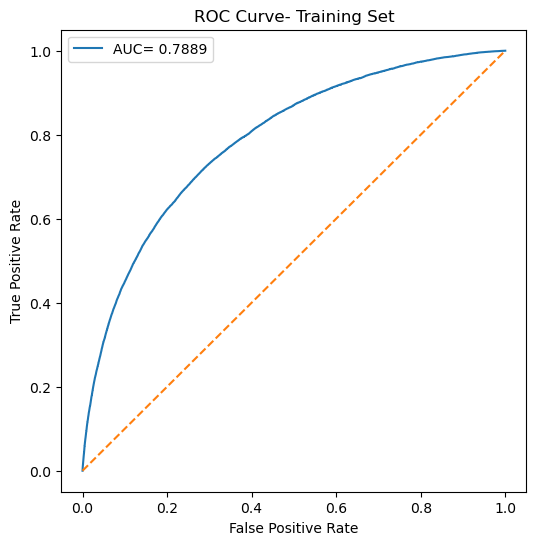

In [108]:
# plotting ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label= f'AUC= {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Training Set')
plt.legend()
plt.show()

In [109]:
# gini
gini= 2* auc-1

print(f'Gini Coefficient: {gini:.4f}')

Gini Coefficient: 0.5779


In [110]:
# KS statistic
from scipy.stats import ks_2samp

ks_statistic= ks_2samp(
    y_train_pred_proba[y_train== 0],
    y_train_pred_proba[y_train== 1]
).statistic

print(f"KS Statistic: {ks_statistic:.4f}")

KS Statistic: 0.4325


In [111]:
# evaluation for validation dataset
# ROC & AUC
fpr_val, tpr_val, thresholds_val= roc_curve(y_validation, y_validation_pred_proba)

auc_val= roc_auc_score(y_validation, y_validation_pred_proba)

print(f"Validation AUC: {auc_val:.4f}")

Validation AUC: 0.7843


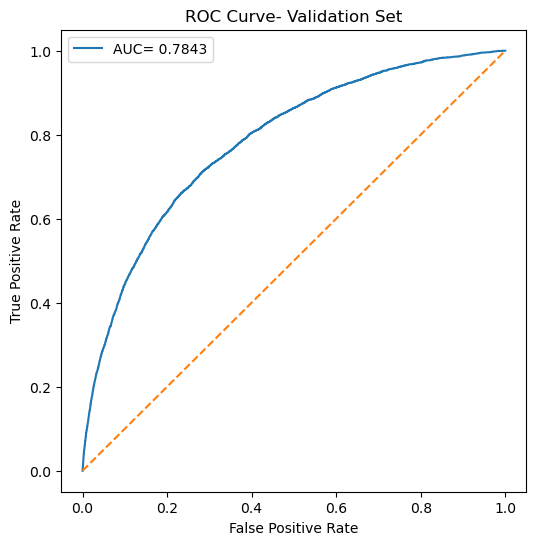

In [112]:
# ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr_val, tpr_val, label= f'AUC= {auc_val:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Validation Set')
plt.legend()
plt.show()

In [113]:
# gini
gini_val= 2* auc_val - 1
print(f'Validation Gini: {gini_val:.4f}')

Validation Gini: 0.5685


In [114]:
# KS statistic
ks_val= ks_2samp(
    y_validation_pred_proba[y_validation== 0],
    y_validation_pred_proba[y_validation== 1]
).statistic

print(f"Validation KS: {ks_val:.4f}")

Validation KS: 0.4286


In [115]:
# evaluation for oot dataset
# ROC & AUC
fpr_oot, tpr_oot, thresholds_oot= roc_curve(y_oot, y_oot_pred_proba)

auc_oot= roc_auc_score(y_oot, y_oot_pred_proba)

print(f'OOT AUC: {auc_oot:.4f}')

OOT AUC: 0.7871


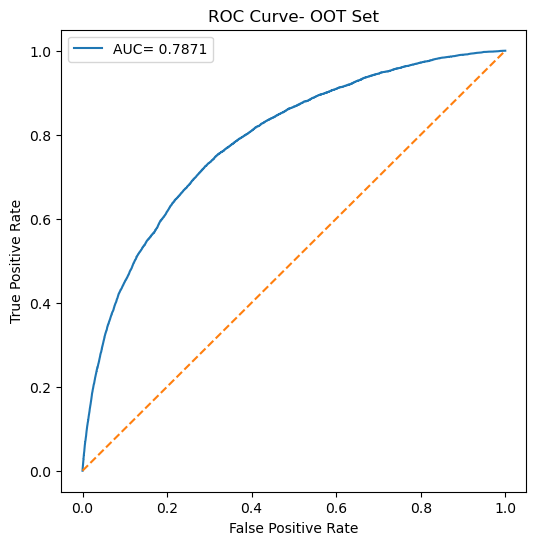

In [116]:
# ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr_oot, tpr_oot, label= f'AUC= {auc_oot:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- OOT Set')
plt.legend()
plt.show()

In [117]:
# gini
gini_oot= 2* auc_oot - 1
print(f"OOT Gini: {gini_oot:.4f}")

OOT Gini: 0.5743


In [118]:
# ks
ks_oot= ks_2samp(
    y_oot_pred_proba[y_oot== 0],
    y_oot_pred_proba[y_oot== 1]
).statistic

print(f'OOT KS: {ks_oot:.4f}')

OOT KS: 0.4348


In [119]:
# decile table

def create_decile_table(y_true, y_pred_proba):
    
    # Create DataFrame
    df = pd.DataFrame({
        'actual': y_true,
        'predicted_pd': y_pred_proba
    })

    # Sort by predicted PD (highest risk first)
    df = df.sort_values('predicted_pd', ascending=False).reset_index(drop=True)

    # Create deciles
    df['decile'] = pd.qcut(df.index, 10, labels=range(1, 11))

    # Aggregate statistics
    decile_table = (
        df.groupby('decile', observed=False)
        .agg(
            total_accounts=('actual', 'count'),
            total_bads=('actual', 'sum'),
            avg_predicted_pd=('predicted_pd', 'mean')
        )
        .reset_index()
    )

    # Calculate additional metrics
    decile_table['total_goods'] = (
        decile_table['total_accounts'] - decile_table['total_bads']
    )

    decile_table['observed_bad_rate'] = (
        decile_table['total_bads'] / decile_table['total_accounts']
    )

    decile_table['cum_bads'] = decile_table['total_bads'].cumsum()
    decile_table['cum_goods'] = decile_table['total_goods'].cumsum()

    total_bads = decile_table['total_bads'].sum()
    total_goods = decile_table['total_goods'].sum()

    decile_table['cum_bad_pct'] = (
        decile_table['cum_bads'] / total_bads
    )

    decile_table['cum_good_pct'] = (
        decile_table['cum_goods'] / total_goods
    )

    decile_table['ks'] = (
        decile_table['cum_bad_pct'] - decile_table['cum_good_pct']
    ).abs()

    overall_bad_rate = total_bads / decile_table['total_accounts'].sum()

    decile_table['lift'] = (
        decile_table['observed_bad_rate'] / overall_bad_rate
    )

    return decile_table

In [120]:
# development
decile_train= create_decile_table(y_train, y_train_pred_proba)
decile_train

,decile,total_accounts,total_bads,avg_predicted_pd,total_goods,observed_bad_rate,cum_bads,cum_goods,cum_bad_pct,cum_good_pct,ks,lift
0,1,60204,9174,0.152249,51030,0.152382,9174,51030,0.422862,0.087932,0.334931,4.228575
1,2,60203,3898,0.066106,56305,0.064748,13072,107335,0.602535,0.184953,0.417583,1.796736
2,3,60203,2472,0.042209,57731,0.041061,15544,165066,0.716478,0.284431,0.432048,1.139439
3,4,60203,1751,0.029890,58452,0.029085,17295,223518,0.797188,0.385151,0.412037,0.807102
4,5,60204,1438,0.021923,58766,0.023885,18733,282284,0.863471,0.486413,0.377058,0.662818
5,6,60203,1040,0.016209,59163,0.017275,19773,341447,0.911408,0.588359,0.323049,0.479376
6,7,60203,750,0.012148,59453,0.012458,20523,400900,0.945978,0.690804,0.255174,0.345703
7,8,60203,581,0.009047,59622,0.009651,21104,460522,0.972759,0.793541,0.179218,0.267805
8,9,60203,374,0.006485,59829,0.006212,21478,520351,0.989998,0.896634,0.093363,0.172391
9,10,60204,217,0.004094,59987,0.003604,21695,580338,1.000000,1.000000,0.000000,0.100022


In [121]:
# validation
decile_validation= create_decile_table(y_validation, y_validation_pred_proba)
decile_validation

,decile,total_accounts,total_bads,avg_predicted_pd,total_goods,observed_bad_rate,cum_bads,cum_goods,cum_bad_pct,cum_good_pct,ks,lift
0,1,13197,1984,0.151671,11213,0.150337,1984,11213,0.410681,0.088201,0.322480,4.106530
1,2,13196,901,0.065882,12295,0.068278,2885,23508,0.597185,0.184913,0.412272,1.865052
2,3,13196,555,0.042016,12641,0.042058,3440,36149,0.712068,0.284347,0.427721,1.148839
3,4,13196,382,0.029701,12814,0.028948,3822,48963,0.791141,0.385141,0.405999,0.790733
4,5,13196,316,0.021838,12880,0.023947,4138,61843,0.856551,0.486455,0.370097,0.654114
5,6,13196,249,0.016189,12947,0.018869,4387,74790,0.908094,0.588295,0.319798,0.515425
6,7,13196,175,0.012148,13021,0.013262,4562,87811,0.944318,0.690718,0.253600,0.362247
7,8,13196,130,0.009048,13066,0.009851,4692,100877,0.971227,0.793495,0.177733,0.269097
8,9,13196,80,0.006467,13116,0.006062,4772,113993,0.987787,0.896665,0.091122,0.165598
9,10,13196,59,0.004060,13137,0.004471,4831,127130,1.000000,1.000000,0.000000,0.122129


In [122]:
# oot
decile_oot= create_decile_table(y_oot, y_oot_pred_proba)
decile_oot

,decile,total_accounts,total_bads,avg_predicted_pd,total_goods,observed_bad_rate,cum_bads,cum_goods,cum_bad_pct,cum_good_pct,ks,lift
0,1,24396,3756,0.151938,20640,0.153960,3756,20640,0.425416,0.087781,0.337635,4.254145
1,2,24396,1504,0.066023,22892,0.061649,5260,43532,0.595764,0.185140,0.410624,1.703470
2,3,24396,1077,0.042012,23319,0.044147,6337,66851,0.717748,0.284315,0.433433,1.219839
3,4,24396,718,0.029734,23678,0.029431,7055,90529,0.799071,0.385017,0.414054,0.813226
4,5,24396,549,0.021753,23847,0.022504,7604,114376,0.861253,0.486437,0.374815,0.621812
5,6,24395,388,0.016113,24007,0.015905,7992,138383,0.905199,0.588538,0.316661,0.439477
6,7,24396,336,0.012105,24060,0.013773,8328,162443,0.943255,0.690865,0.252391,0.380562
7,8,24396,236,0.009030,24160,0.009674,8564,186603,0.969985,0.793616,0.176369,0.267300
8,9,24396,177,0.006472,24219,0.007255,8741,210822,0.990033,0.896619,0.093414,0.200475
9,10,24396,88,0.004088,24308,0.003607,8829,235130,1.000000,1.000000,0.000000,0.099671


In [123]:
# calibration
import matplotlib.pyplot as plt

# ==============================
# Calibration Check
# ==============================

def plot_calibration(decile_table, dataset_name):
    
    plt.figure(figsize=(6,4))

    plt.plot(
        decile_table['decile'],
        decile_table['avg_predicted_pd'],
        marker='o',
        label='Average Predicted PD'
    )

    plt.plot(
        decile_table['decile'],
        decile_table['observed_bad_rate'],
        marker='s',
        label='Observed Bad Rate'
    )

    plt.xlabel('Decile (1 = Highest Risk)')
    plt.ylabel('Probability of Default')
    plt.title(f'Calibration Check - {dataset_name}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

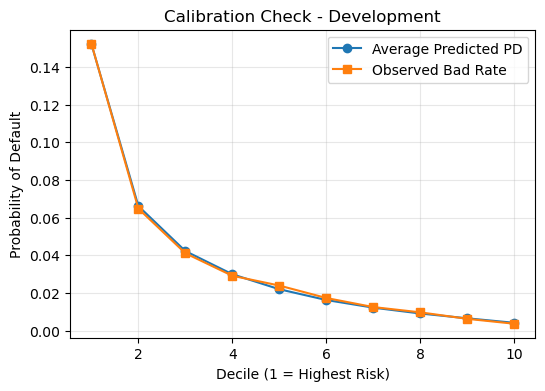

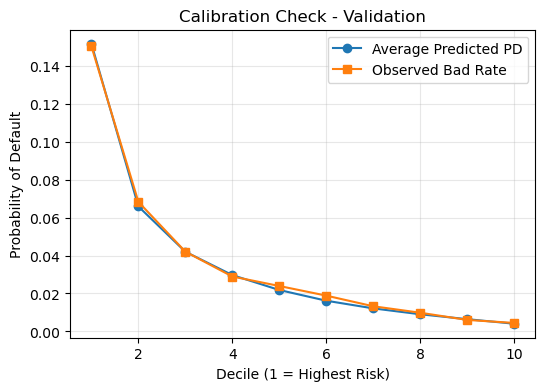

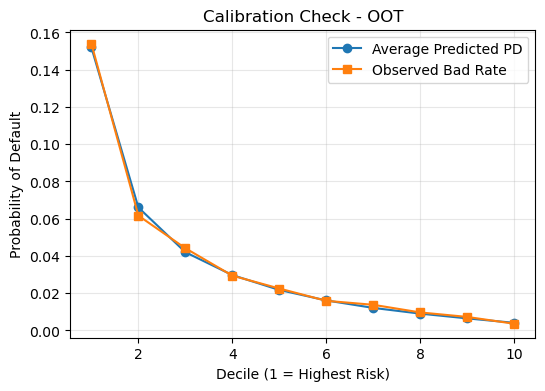

In [124]:
plot_calibration(decile_train, "Development")
plot_calibration(decile_validation, "Validation")
plot_calibration(decile_oot, "OOT")

The calibration plots show that the predicted PD closely matches the observed default rate across all deciles in the Development, Validation, and OOT datasets. This indicates that the model is well calibrated and produces reliable probability estimates while maintaining stable performance across different datasets.

In [125]:
pd_predictions = pd.DataFrame(
    {
        "acct_id": oot_data["acct_id"],
        "snapshot_dt": oot_data["snapshot_dt"],
        "pd_pred": y_oot_pred_proba,
    }
)

pd_predictions.to_csv(
    "../data/processed/pd_predictions.csv",
    index=False,
)


In [126]:
pd_pipeline = {
    "model": result_final,
    "categorical_woe_tables": woe_tables,
    "continuous_binning_process": binning_process,
    "accepted_categorical": accepted_categorical,
    "accepted_continuous": accepted_continuous,
    "variables_to_drop": variables_to_drop,
    "final_features": final_features,
    "imputation_values": {
        "emp_length_yrs": emp_length_median,
        "bureau_score_2": bureau_score_2_median,
        "d_mob_since_last_delinq_cnt": d_mob_since_last_delinq_median,
        "p_days_since_last_pay_cnt": p_days_since_last_pay_median,
        "dti_ratio": dti_ratio_median,
    },
}


In [127]:
import pickle

with open("../saved_objects/pd_pipeline.pkl", "wb") as f:
    pickle.dump(pd_pipeline, f)

### Scorecard Development

In [128]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [129]:
from src.preprocessing import build_scorecard_table

scorecard = build_scorecard_table(
    result_final,
    woe_tables,
    binning_process,
)

scorecard.head()


,feature,category,woe,coefficient,iv
0,d_curr_delinq_bucket_cd,1-29,-0.252745,-0.077548,0.011550
1,d_curr_delinq_bucket_cd,30-59,-0.989479,-0.077548,0.153521
2,d_curr_delinq_bucket_cd,60-89,-1.720500,-0.077548,0.311102
3,d_curr_delinq_bucket_cd,C,0.771495,-0.077548,0.294457
4,d_times_60dpd_12m_cnt,0,0.289017,-0.244963,0.068101


### Score Scaling

In [130]:
BASE_SCORE = 600
PDO = 50
BASE_ODDS = 50

In [131]:
factor = PDO / np.log(2)

offset = (
    BASE_SCORE
    - factor * np.log(BASE_ODDS)
)

print(f"Factor: {factor:.4f}")
print(f"Offset: {offset:.4f}")

Factor: 72.1348
Offset: 317.8072


In [132]:
n_features = scorecard["feature"].nunique()

print(n_features)


14


In [133]:
# Intercept coefficient
intercept = result_final.params["const"]

# Intercept score
intercept_points = (
    offset / n_features
    - factor * intercept / n_features
)

print(f"Intercept Coefficient: {intercept:.6f}")
print(f"Intercept Points per Variable: {intercept_points:.2f}")


Intercept Coefficient: -3.287090
Intercept Points per Variable: 39.64


In [134]:
# Calculate scorecard points

scorecard["points"] = (
    intercept_points
    - factor
    * scorecard["coefficient"]
    * scorecard["woe"]
).round(0).astype(int)

scorecard.head()


,feature,category,woe,coefficient,iv,points
0,d_curr_delinq_bucket_cd,1-29,-0.252745,-0.077548,0.011550,38
1,d_curr_delinq_bucket_cd,30-59,-0.989479,-0.077548,0.153521,34
2,d_curr_delinq_bucket_cd,60-89,-1.720500,-0.077548,0.311102,30
3,d_curr_delinq_bucket_cd,C,0.771495,-0.077548,0.294457,44
4,d_times_60dpd_12m_cnt,0,0.289017,-0.244963,0.068101,45


In [135]:
scorecard.tail(10)

,feature,category,woe,coefficient,iv,points
109,p_days_since_last_pay_cnt,"[1.50, 2.50)",0.727378,-0.05125,0.041027,42
110,p_days_since_last_pay_cnt,"[2.50, 3.50)",0.417148,-0.05125,0.015089,41
111,p_days_since_last_pay_cnt,"[3.50, 4.50)",0.118539,-0.05125,0.001318,40
112,p_days_since_last_pay_cnt,"[4.50, 5.50)",-0.068331,-0.05125,0.000516,39
113,p_days_since_last_pay_cnt,"[5.50, 6.50)",-0.257883,-0.05125,0.005636,39
114,p_days_since_last_pay_cnt,"[6.50, 7.50)",-0.334946,-0.05125,0.008323,38
115,p_days_since_last_pay_cnt,"[7.50, 11.50)",-0.424278,-0.05125,0.034722,38
116,p_days_since_last_pay_cnt,"[11.50, inf)",-0.445466,-0.05125,0.031791,38
117,p_days_since_last_pay_cnt,Special,0.000000,-0.05125,0.000000,40
118,p_days_since_last_pay_cnt,Missing,0.000000,-0.05125,0.000000,40


In [136]:
# creating a lookup table
score_lookup = scorecard[
    ["feature", "category", "points"]
    ].copy()

score_lookup.head()


,feature,category,points
0,d_curr_delinq_bucket_cd,1-29,38
1,d_curr_delinq_bucket_cd,30-59,34
2,d_curr_delinq_bucket_cd,60-89,30
3,d_curr_delinq_bucket_cd,C,44
4,d_times_60dpd_12m_cnt,0,45


### Scorecard Validation

In [137]:
# Sort scorecard

scorecard = scorecard.sort_values(
    ["feature", "points"],
    ascending=[True, False],
).reset_index(drop=True)

scorecard.head(20)

,feature,category,woe,coefficient,iv,points
0,b_util_ratio,"(-inf, 0.00)",1.805367,-0.112227,0.107845,54
1,b_util_ratio,"[0.00, 0.07)",1.505931,-0.112227,0.061125,52
2,b_util_ratio,"[0.07, 0.15)",1.264177,-0.112227,0.074305,50
3,b_util_ratio,"[0.15, 0.19)",1.014770,-0.112227,0.033399,48
4,b_util_ratio,"[0.19, 0.24)",0.822194,-0.112227,0.038719,46
5,b_util_ratio,"[0.24, 0.28)",0.635562,-0.112227,0.015324,45
6,b_util_ratio,"[0.28, 0.31)",0.511749,-0.112227,0.013256,44
7,b_util_ratio,"[0.31, 0.36)",0.347710,-0.112227,0.008764,42
8,b_util_ratio,"[0.36, 0.40)",0.158844,-0.112227,0.001708,41
9,b_util_ratio,"[0.40, 0.44)",0.036554,-0.112227,0.000070,40


In [138]:
scorecard.groupby("feature").agg(
    bins=("category", "count"),
    min_points=("points", "min"),
    max_points=("points", "max"),
)

,bins,min_points,max_points
feature,,,
b_util_ratio,17,28,54
bureau_score,18,-22,131
d_cure_flag,2,37,40
d_curr_delinq_bucket_cd,4,30,44
d_mob_since_last_delinq_cnt,4,31,45
d_times_60dpd_12m_cnt,3,5,45
delinq_trades_cnt,5,36,41
dti_ratio,7,36,40
inq_12m_cnt,9,26,54


In [139]:
scorecard.to_csv(
    "../saved_objects/pd_scorecard.csv",
    index=False,
)

print("PD scorecard saved successfully.")

PD scorecard saved successfully.


In [140]:
score_scaling = {
    "base_score": BASE_SCORE,
    "pdo": PDO,
    "base_odds": BASE_ODDS,
    "factor": factor,
    "offset": offset,
    "intercept_points": intercept_points,
}

with open("../saved_objects/score_scaling.pkl", "wb") as f:
    pickle.dump(score_scaling, f)

print("Score scaling parameters saved successfully.")

Score scaling parameters saved successfully.
